In [82]:
!python nopants_train.py --nepoch 600 --save_path 'results/yolov3_07' --ctrl 50 --arch "yolov3" --seed_type variable --clamp_shift 0.01 --loss_type max_iou --seed_ratio 0.7 --device 'cuda' --num_points_tshirt=10

Version 2.0
Train info: Namespace(device='cuda', lr=0.001, lr_seed=0.01, nepoch=600, checkpoints=0, batch_size=4, save_path='results/yolov3_07', alpha=10, tv_loss=0, lr_decay=2, lr_decay_seed=2, blur=1, like=1, ctrl=50.0, num_points_tshirt=10, num_points_trouser=60, arch='yolov3', cdist=0, seed_type='variable', rd_num=200, clamp_shift=0.01, resample_type=None, seed_temp=1.0, seed_opt='adam', tps2d_range_t=50.0, tps2d_range_r=0.1, tps3d_range=0.15, disable_tps2d=False, disable_tps3d=False, disable_test_tps2d=False, disable_test_tps3d=False, seed_ratio=0.7, loss_type='max_iou', test=False, test_iou=0.1, test_nms_thresh=1.0, test_mode='person', test_suffix='', train_iou=0.01, anneal=False, anneal_init=5.0, anneal_alpha=3.0)
One training epoch has 376 images
One test epoch has 130 images
/home/cynthia/miniforge3/envs/camo/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered in

In [14]:
import torch
import sys
sys.path.append("../diffSLIC")
from diffSLIC import *
# from PIL import Image
from skimage.io import imread

slic_fn = DiffSLIC(n_spixels=100, n_iter=5, tau=0.1, candidate_radius=1, stable=True)

rgb_img = torch.from_numpy(np.moveaxis(np.asarray(Image.open("test.png").convert('RGB')), -1, 0)[None,:].astype(np.float32))
rgb_img.div_(255)
print(rgb_img.shape)

colors = torch.tensor([
    [236, 218, 192],
    [83, 100, 116],
    [12, 156, 194],
    [105, 115, 84],
    [211, 219, 207],
    [191, 214, 203],
    [46, 113, 75],
    [157, 178, 194],
    [194, 192, 172]
]).float()
color_palette = torch.div(colors, 255.)

features, spix2pix_assign, pix2spix_assign = slic_fn(rgb_img)
print(features.shape, spix2pix_assign.shape, pix2spix_assign.shape)

h_s, w_s = features.shape[-2:]
hard_assign = torch.nn.functional.one_hot(spix2pix_assign.argmax(1), (2 * 1 + 1)**2).permute(0, 3, 1, 2).contiguous().float()
label = torch.arange(h_s * w_s, dtype=torch.float).reshape(1, 1, h_s, w_s)
label = spixel_upsampling(label, hard_assign, candidate_radius=1)
res = spixel_downsampling(rgb_img, pix2spix_assign, candidate_radius=1)
print(label.shape, res.shape)

torch.Size([1, 3, 364, 864])
6 864 364
torch.Size([1, 3, 6, 15]) torch.Size([1, 9, 364, 864]) torch.Size([1, 31842, 6, 15])
torch.Size([1, 1, 364, 864]) torch.Size([1, 3, 6, 15])


(314496, 3)


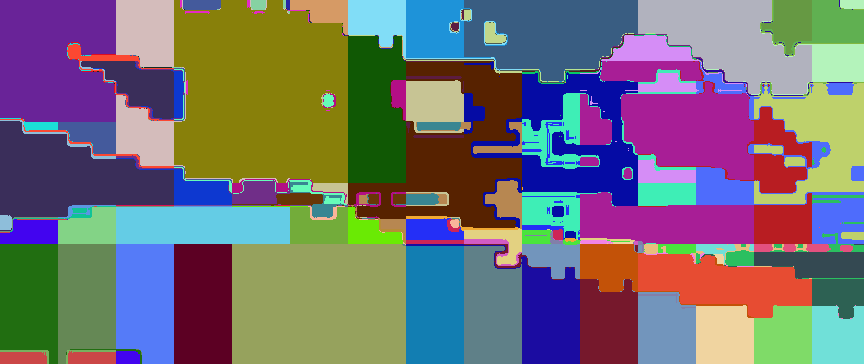

#Superpixels 101


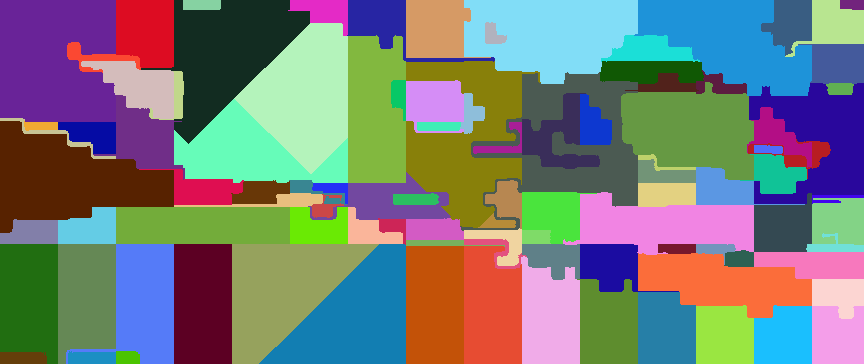

In [15]:
from scipy.misc import face
from skimage.segmentation import mark_boundaries
from skimage.segmentation.slic_superpixels import _enforce_label_connectivity_cython

np_lbl = label[0,0].long().numpy()
# fig = plt.figure(figsize=(24, 12))
# ax1 = fig.add_subplot(2, 2, 1) # top left
# raw spixels' boundaries
rgb_lbl, color_palette = lbl_to_rgb(np_lbl)
print(color_palette.shape)
# raw spixels with random color
Image.fromarray(rgb_lbl).show()
# # enforce connectivity
h = 364
w = 864
segment_size = h * w / (h_s * w_s)
min_size = int(0.06 * segment_size)
max_size = int(3.0 * segment_size)
np_lbl = _enforce_label_connectivity_cython(np_lbl[None], min_size, max_size)[0]
valid_n_spixel = len(np.unique(np_lbl))
print(f"#Superpixels {valid_n_spixel}")
# ax3 = fig.add_subplot(2, 2, 3) # bottom left
# # spixels' boundaries after postprocessing
# ax3.imshow(mark_boundaries(face(), np_lbl))
# ax4 = fig.add_subplot(2, 2, 4) # bottom right
# # spixels with random colos after postprocessing
Image.fromarray(lbl_to_rgb(np_lbl, color_palette)[0]).show()

In [83]:
from nopants_train import *
import argparse
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [91]:
parser = argparse.ArgumentParser(description='PyTorch Training')
parser.add_argument('--device', default='cuda:1', help='')
parser.add_argument('--lr', type=float, default=0.001, help='')
parser.add_argument('--lr_seed', type=float, default=0.01, help='')
parser.add_argument('--nepoch', type=int, default=600, help='')
parser.add_argument('--checkpoints', type=int, default=0, help='')
parser.add_argument('--batch_size', type=int, default=4, help='')
parser.add_argument('--save_path', default='results/', help='')
parser.add_argument("--alpha", type=float, default=10, help='')
parser.add_argument("--tv_loss", type=float, default=0, help='')
parser.add_argument("--lr_decay", type=float, default=2, help='')
parser.add_argument("--lr_decay_seed", type=float, default=2, help='')
parser.add_argument("--blur", type=float, default=1, help='')
parser.add_argument("--like", type=float, default=1, help='')
parser.add_argument("--ctrl", type=float, default=1, help='')
parser.add_argument("--num_points_tshirt", type=int, default=60, help='')
parser.add_argument("--num_points_trouser", type=int, default=60, help='')
parser.add_argument("--arch", type=str, default="rcnn")
parser.add_argument("--cdist", type=float, default=0, help='')
parser.add_argument("--seed_type", default='fixed', help='fixed, random, variable, langevin')
parser.add_argument("--rd_num", type=int, default=200, help='')
parser.add_argument("--clamp_shift", type=float, default=0, help='')
parser.add_argument("--resample_type", default=None, help='')
parser.add_argument("--seed_temp", type=float, default=1.0, help='')
parser.add_argument("--seed_opt", default='adam', help='')
parser.add_argument("--tps2d_range_t", type=float, default=50.0, help='')
parser.add_argument("--tps2d_range_r", type=float, default=0.1, help='')
parser.add_argument("--tps3d_range", type=float, default=0.15, help='')
parser.add_argument("--disable_tps2d", default=False, action='store_true', help='')
parser.add_argument("--disable_tps3d", default=False, action='store_true', help='')
parser.add_argument("--disable_test_tps2d", default=False, action='store_true', help='')
parser.add_argument("--disable_test_tps3d", default=False, action='store_true', help='')
parser.add_argument("--seed_ratio", default=1.0, type=float, help='The ratio of trainable part when seed type is variable')
parser.add_argument("--loss_type", default='max_iou', help='max_iou, max_conf, softplus_max, softplus_sum')
parser.add_argument("--loss_ssim", default=0.3, help='constant dictating weight of SSIM loss to force texture similarity to image')
parser.add_argument("--test", default=False, action='store_true', help='')
parser.add_argument("--test_iou", type=float, default=0.1, help='')
parser.add_argument("--test_nms_thresh", type=float, default=1.0, help='')
parser.add_argument("--test_mode", default='person', help='person, all')
parser.add_argument("--test_suffix", default='', help='')
parser.add_argument("--train_iou", type=float, default=0.01, help='')
parser.add_argument("--anneal", default=False, action='store_true', help='')
parser.add_argument("--anneal_init", type=float, default=5.0, help='')
parser.add_argument("--anneal_alpha", type=float, default=3.0, help='')

args = parser.parse_args(args = "--num_points_tshirt 10 --nepoch 1 --save_path results/yolov3_07 --ctrl 50 --arch yolov3 --seed_type variable --clamp_shift 0.01 --loss_type max_iou --seed_ratio 0.7 --device cuda".split())
assert args.seed_type in ['fixed', 'random', 'variable', 'langevin']

torch.manual_seed(123)
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

# print("Train info:", args)
# trainer = PatchTrainer(args)
# if not args.test:
#     trainer.train()
# else:
#     epoch = args.checkpoints - 1
#     trainer.load_weights(args.save_path, epoch)
#     trainer.update_mesh(type='determinate')
#     precision, recall, avg, confs, thetas = trainer.test(conf_thresh=0.01, iou_thresh=args.test_iou, angle_sample=37, use_tps2d=not args.disable_test_tps2d, use_tps3d=not args.disable_test_tps3d, mode=args.test_mode)
#     info = [precision, recall, avg, confs]
#     path = args.save_path + '/' + str(epoch) + 'test_results_tps'
#     path = path + '_iou' + str(args.test_iou).replace('.', '') + '_' + args.test_mode + args.test_suffix
#     path = path + '.npz'
#     np.savez(path, thetas=thetas, info=info)

One training epoch has 376 images
One test epoch has 130 images
0.004371367991327204 0.9954093872779698
max range is 19.587, max number of the bins is 461


  0%|                                                                                                                   | 0/1 [00:00<?, ?it/s]

######################################
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0')
85 215 no


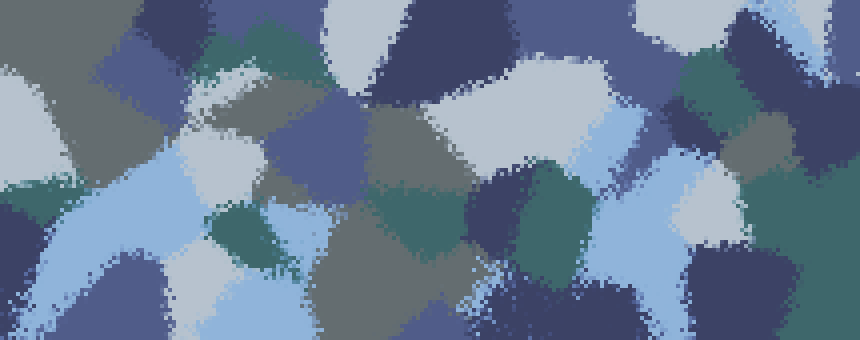

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([44, 4]) bbox
torch.Size([44])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([49, 4]) bbox
torch.Size([49])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
85 215 no


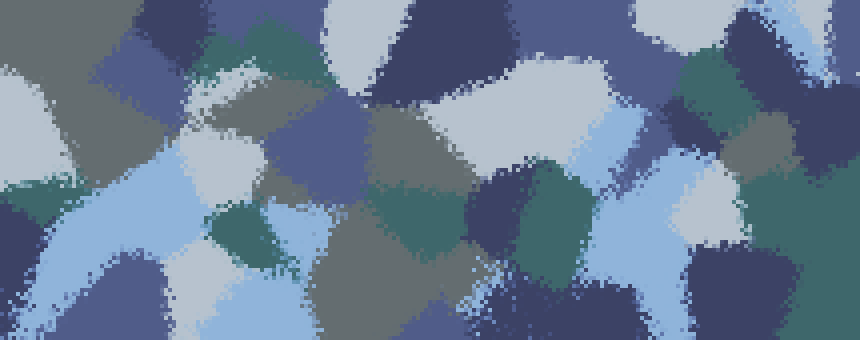

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
85 215 no


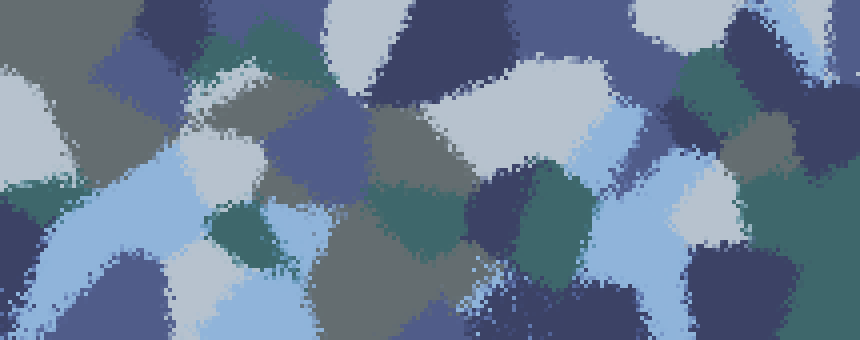

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([20, 4]) bbox
torch.Size([20])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([21, 4]) bbox
torch.Size([21])
IN IOUS max_iou
85 215 no


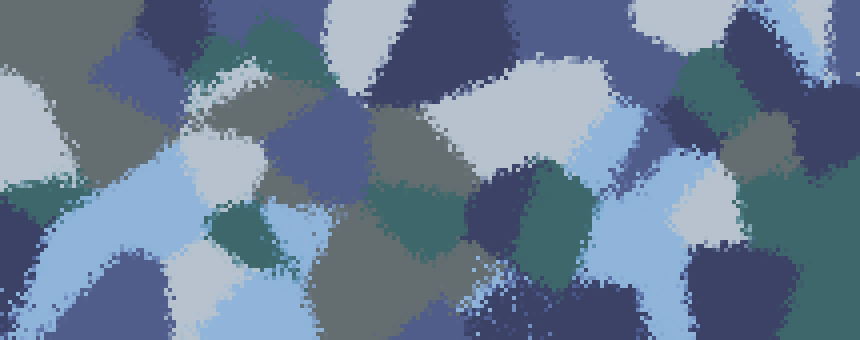

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([17, 4]) bbox
torch.Size([17])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([29, 4]) bbox
torch.Size([29])
IN IOUS max_iou
85 215 no


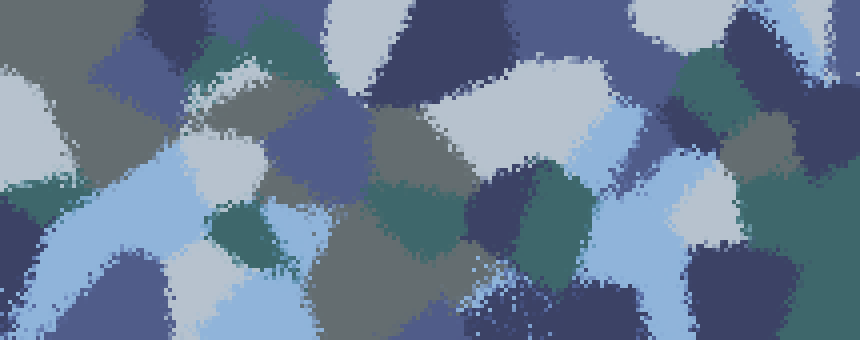

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
85 215 no


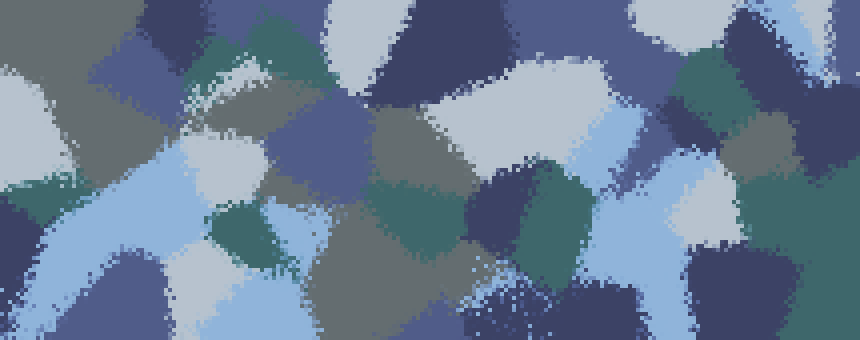

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
85 215 no


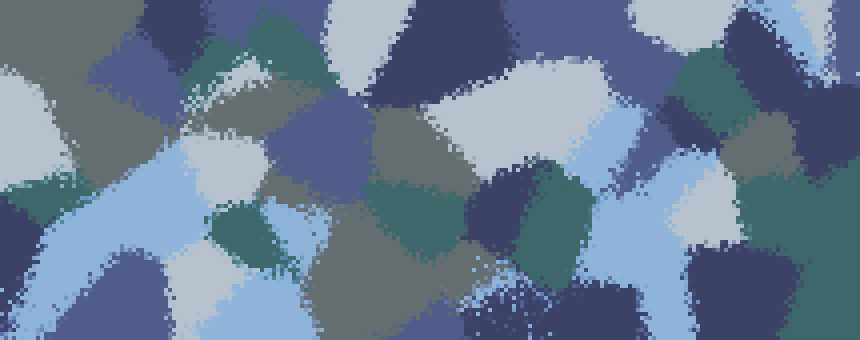

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([64, 4]) bbox
torch.Size([64])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([45, 4]) bbox
torch.Size([45])
IN IOUS max_iou
85 215 no


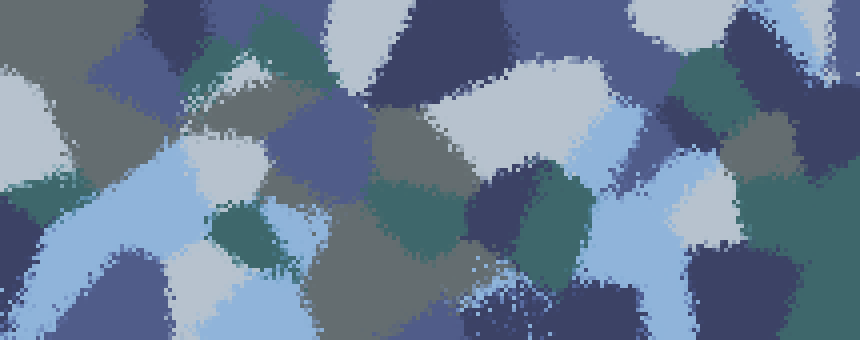

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([22, 4]) bbox
torch.Size([22])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
85 215 no


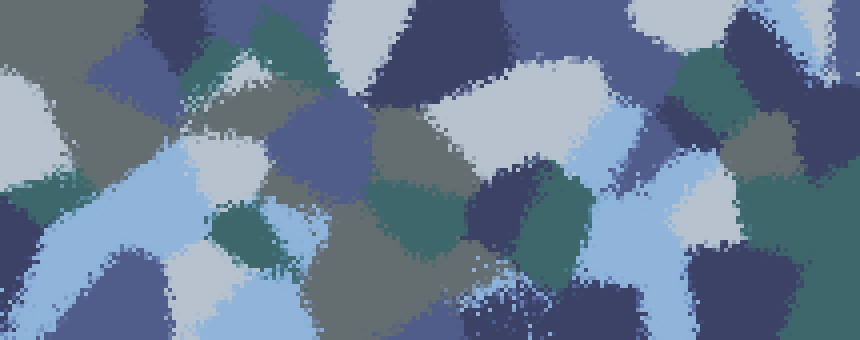

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([15, 4]) bbox
torch.Size([15])
IN IOUS max_iou
True
torch.Size([25, 4]) bbox
torch.Size([25])
IN IOUS max_iou
True
torch.Size([27, 4]) bbox
torch.Size([27])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
85 215 no


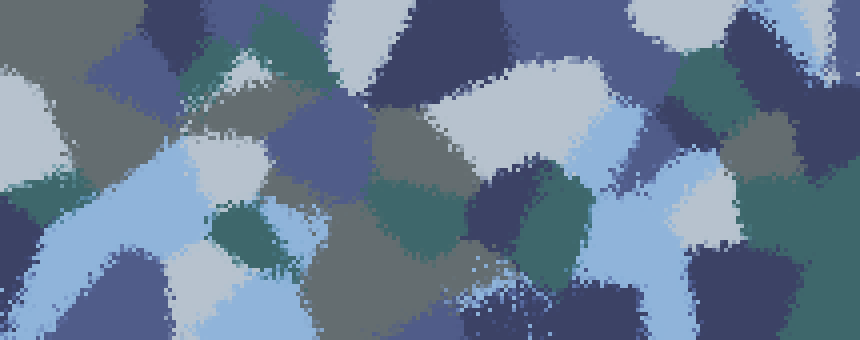

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
85 215 no


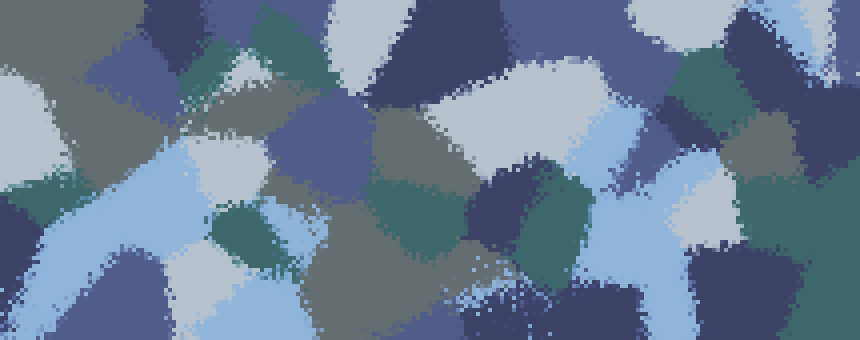

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([16, 4]) bbox
torch.Size([16])
IN IOUS max_iou
True
torch.Size([23, 4]) bbox
torch.Size([23])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
85 215 no


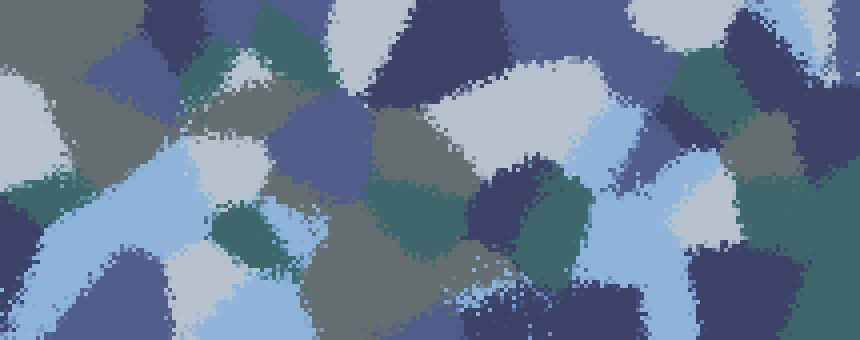

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([18, 4]) bbox
torch.Size([18])
IN IOUS max_iou
True
torch.Size([18, 4]) bbox
torch.Size([18])
IN IOUS max_iou
85 215 no


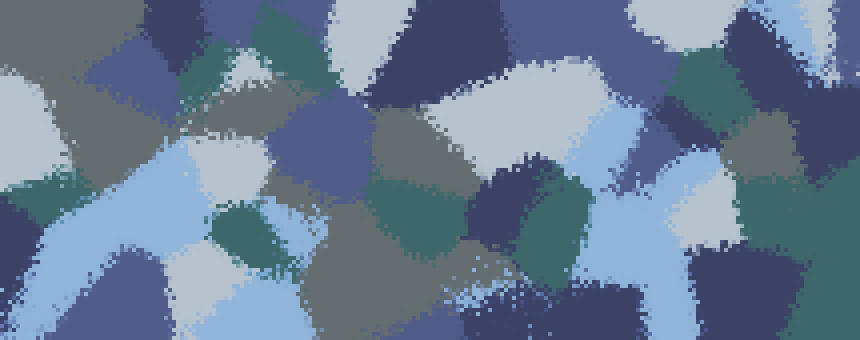

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([32, 4]) bbox
torch.Size([32])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
85 215 no


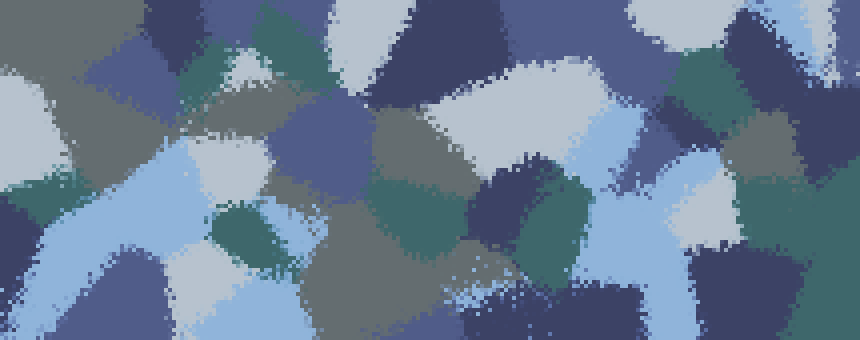

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([16, 4]) bbox
torch.Size([16])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
85 215 no


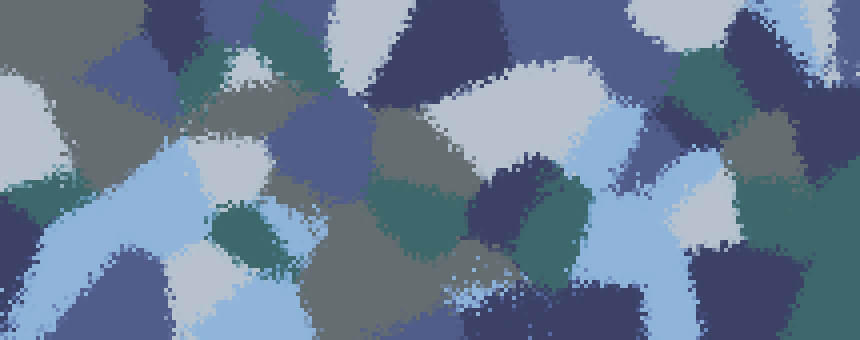

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([11, 4]) bbox
torch.Size([11])
IN IOUS max_iou
85 215 no


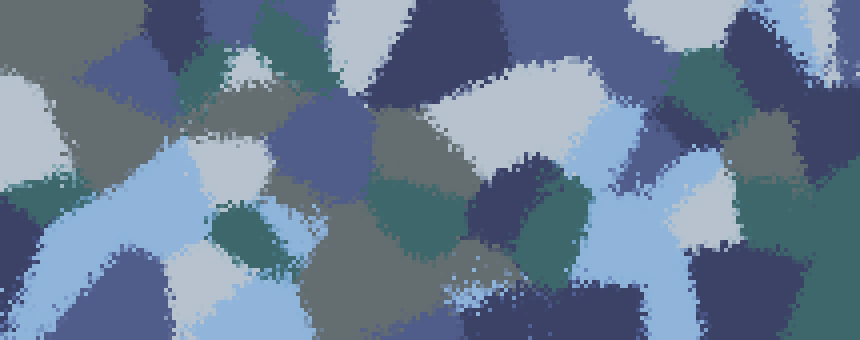

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([25, 4]) bbox
torch.Size([25])
IN IOUS max_iou
True
torch.Size([14, 4]) bbox
torch.Size([14])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
85 215 no


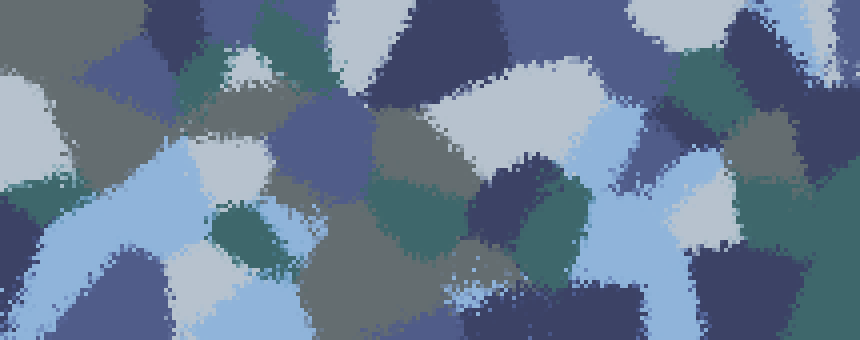

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
85 215 no


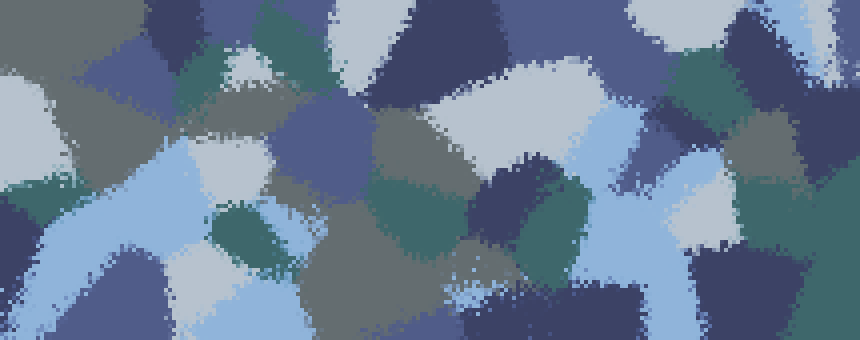

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([14, 4]) bbox
torch.Size([14])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
85 215 no


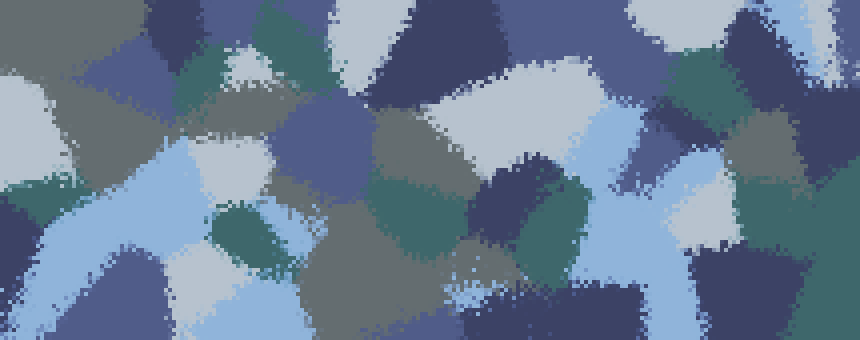

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([61, 4]) bbox
torch.Size([61])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([13, 4]) bbox
torch.Size([13])
IN IOUS max_iou
85 215 no


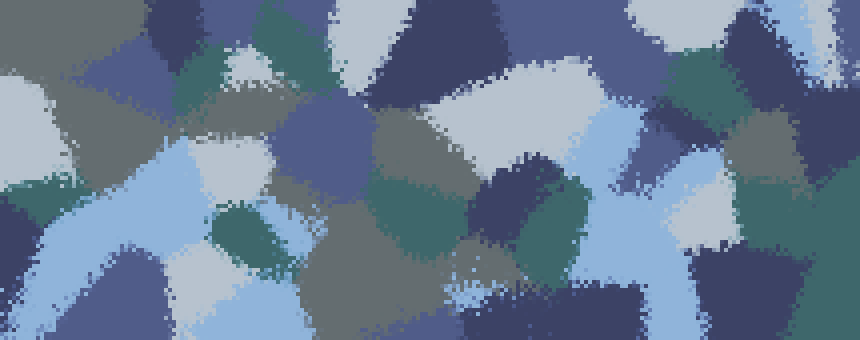

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([18, 4]) bbox
torch.Size([18])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
85 215 no


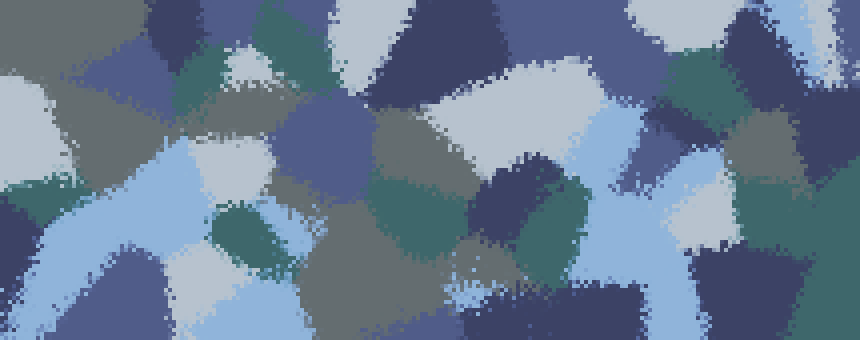

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([128, 4]) bbox
torch.Size([128])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
85 215 no


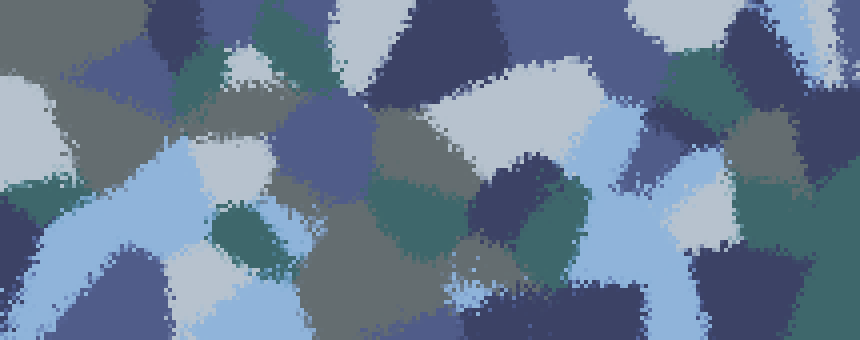

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
85 215 no


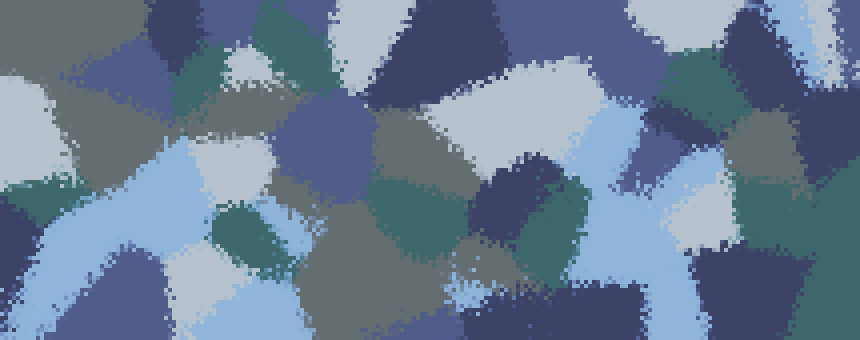

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([14, 4]) bbox
torch.Size([14])
IN IOUS max_iou
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
85 215 no


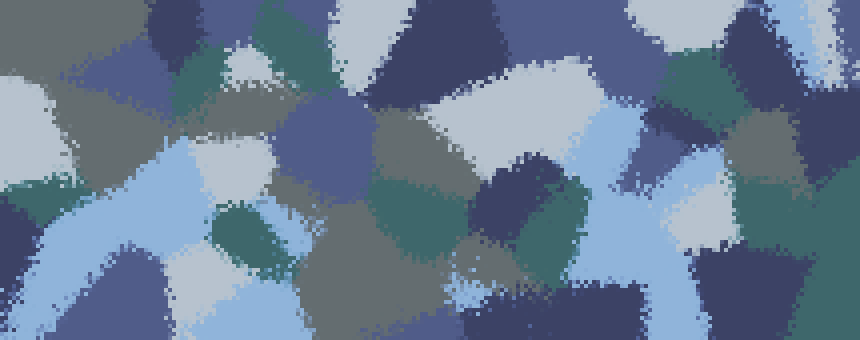

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
85 215 no


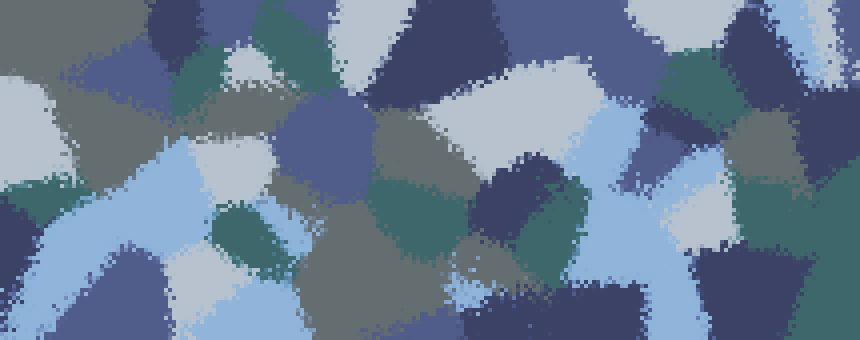

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([28, 4]) bbox
torch.Size([28])
IN IOUS max_iou
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([40, 4]) bbox
torch.Size([40])
IN IOUS max_iou
85 215 no


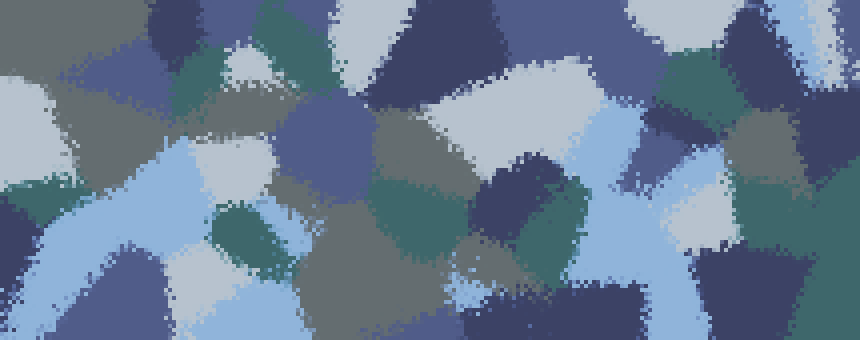

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([17, 4]) bbox
torch.Size([17])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
85 215 no


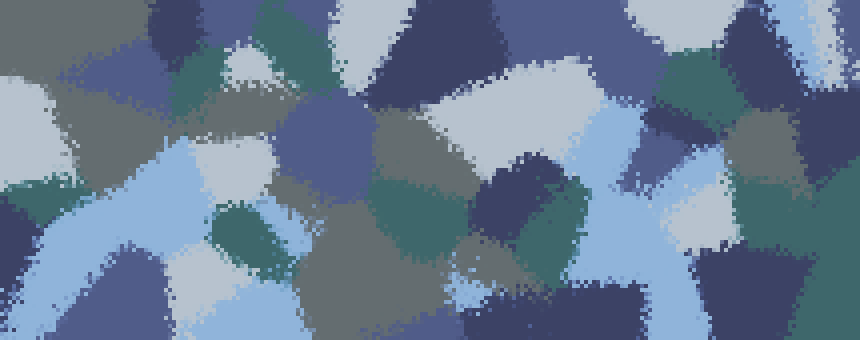

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([15, 4]) bbox
torch.Size([15])
IN IOUS max_iou
True
torch.Size([40, 4]) bbox
torch.Size([40])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
85 215 no


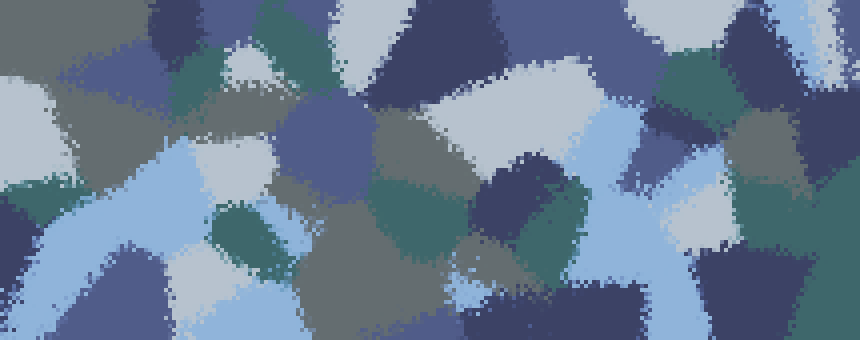

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([15, 4]) bbox
torch.Size([15])
IN IOUS max_iou
True
torch.Size([17, 4]) bbox
torch.Size([17])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
85 215 no


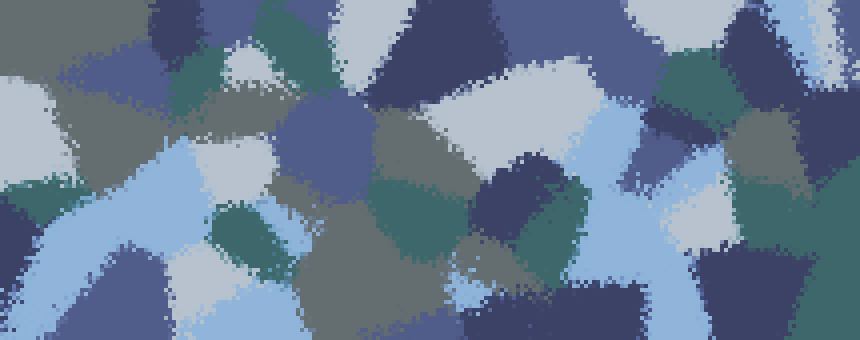

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([19, 4]) bbox
torch.Size([19])
IN IOUS max_iou
True
torch.Size([24, 4]) bbox
torch.Size([24])
IN IOUS max_iou
True
torch.Size([13, 4]) bbox
torch.Size([13])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
85 215 no


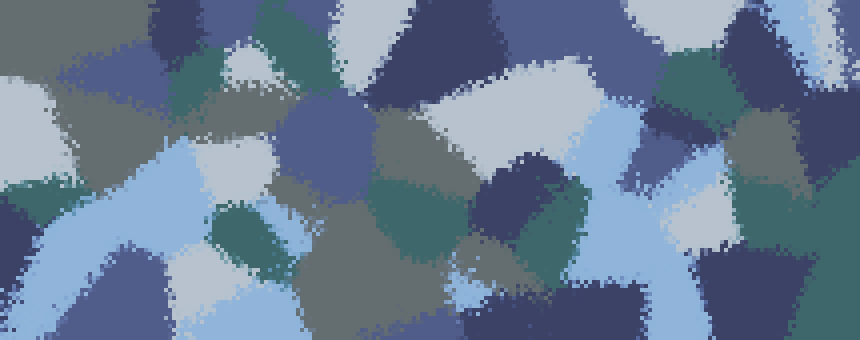

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
85 215 no


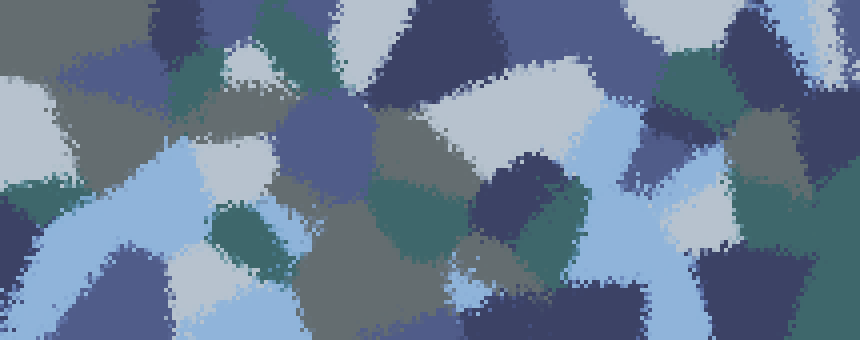

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
85 215 no


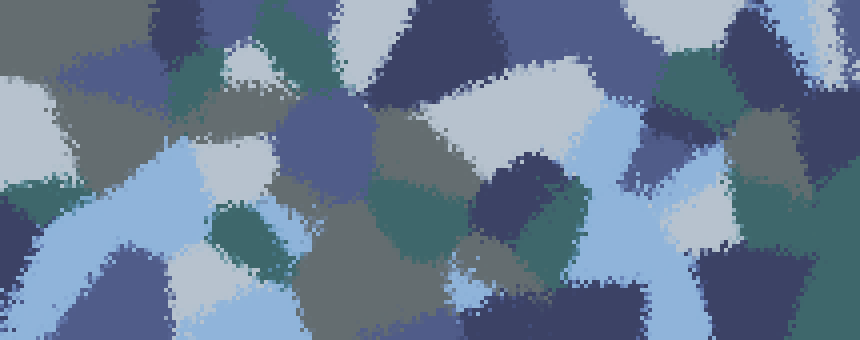

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([21, 4]) bbox
torch.Size([21])
IN IOUS max_iou
True
torch.Size([52, 4]) bbox
torch.Size([52])
IN IOUS max_iou
True
torch.Size([50, 4]) bbox
torch.Size([50])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
85 215 no


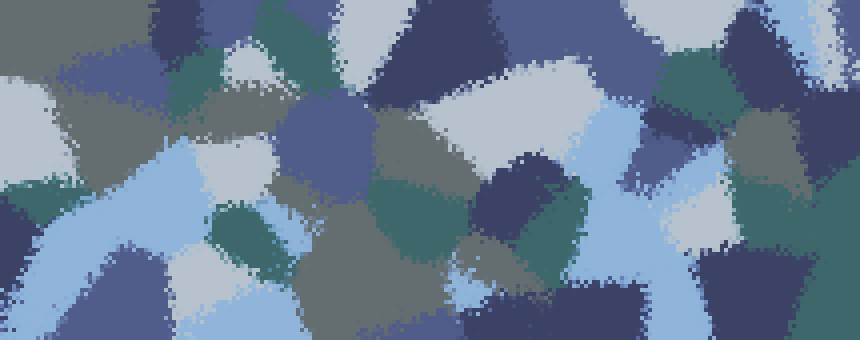

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([11, 4]) bbox
torch.Size([11])
IN IOUS max_iou
True
torch.Size([16, 4]) bbox
torch.Size([16])
IN IOUS max_iou
True
torch.Size([15, 4]) bbox
torch.Size([15])
IN IOUS max_iou
85 215 no


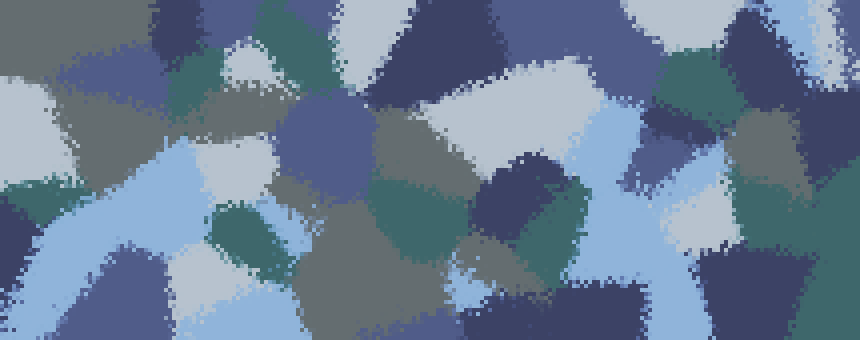

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([20, 4]) bbox
torch.Size([20])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
85 215 no


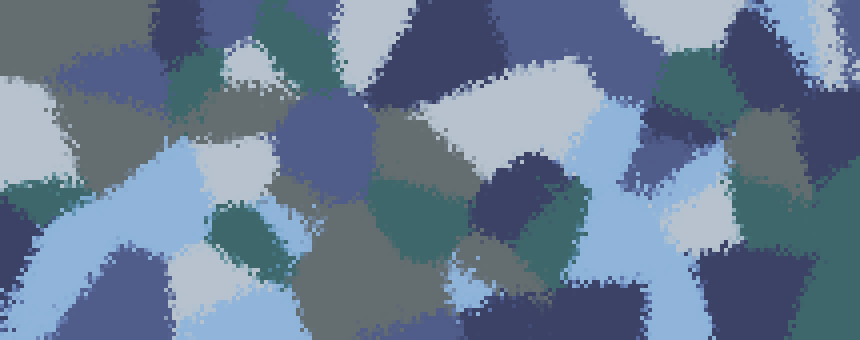

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
85 215 no


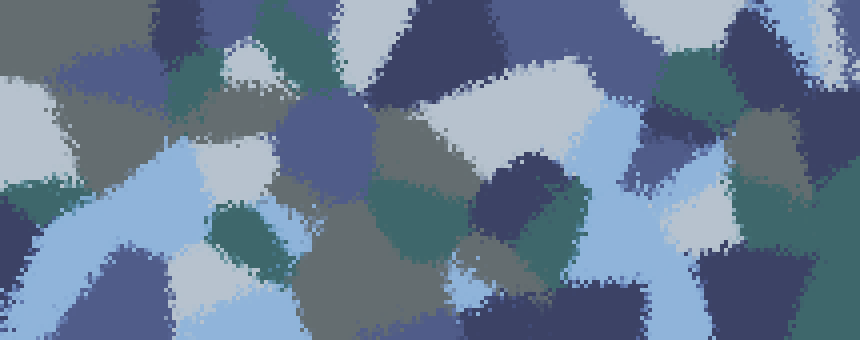

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([24, 4]) bbox
torch.Size([24])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([21, 4]) bbox
torch.Size([21])
IN IOUS max_iou
85 215 no


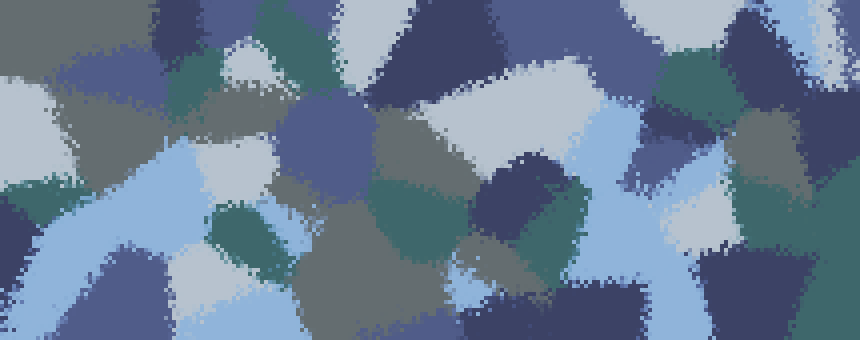

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([11, 4]) bbox
torch.Size([11])
IN IOUS max_iou
True
torch.Size([16, 4]) bbox
torch.Size([16])
IN IOUS max_iou
85 215 no


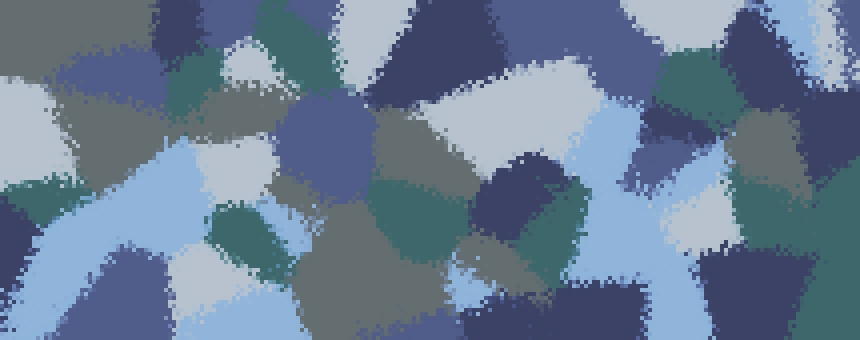

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([13, 4]) bbox
torch.Size([13])
IN IOUS max_iou
True
torch.Size([30, 4]) bbox
torch.Size([30])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
85 215 no


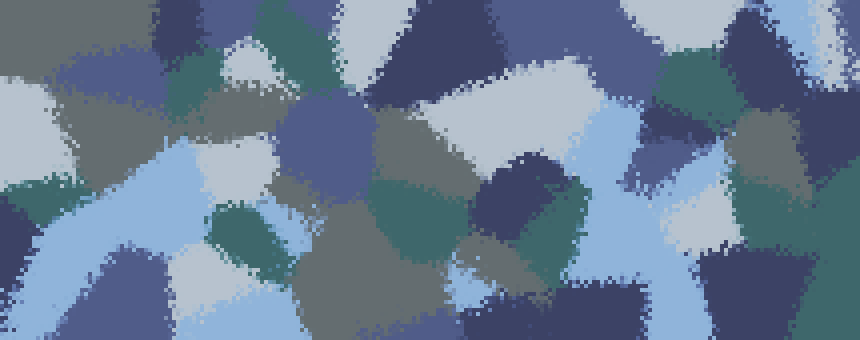

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
85 215 no


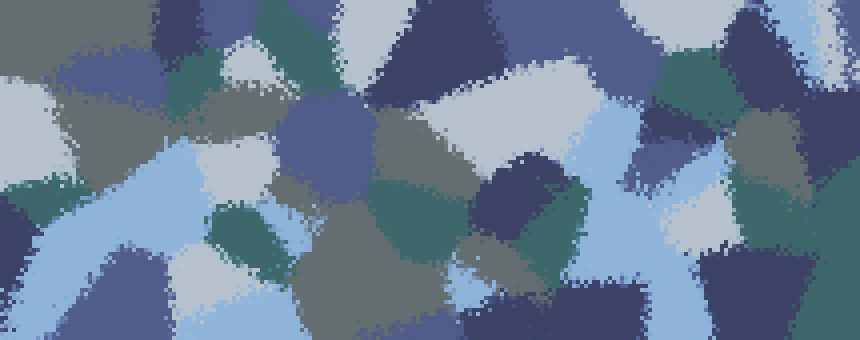

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([11, 4]) bbox
torch.Size([11])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
85 215 no


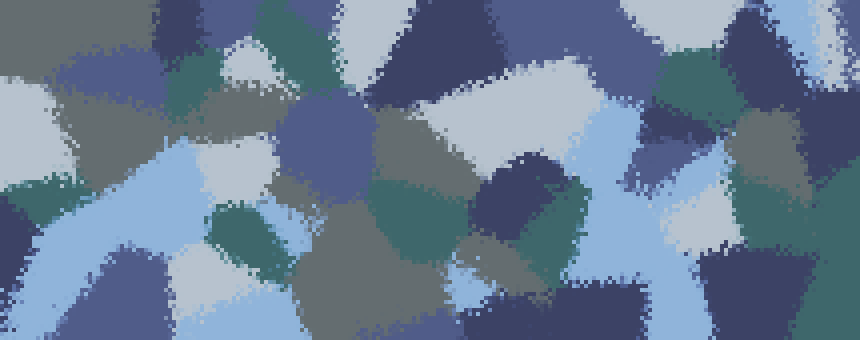

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([51, 4]) bbox
torch.Size([51])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([17, 4]) bbox
torch.Size([17])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
85 215 no


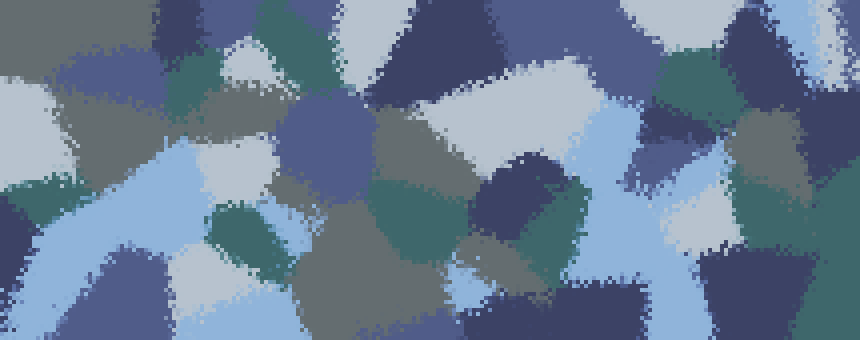

IN SYNTHS


  0%|                                                                                                                   | 0/1 [00:13<?, ?it/s]

torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([23, 4]) bbox
torch.Size([23])
IN IOUS max_iou
85 215 no


KeyboardInterrupt: 

In [92]:
trainer = PatchTrainer(args)
trainer.train()

One training epoch has 376 images
One test epoch has 130 images
(6, 10, 2)
0.0036244138564966483 0.9972839627577214
max range is 19.587, max number of the bins is 461


  0%|                                                                                                                   | 0/1 [00:00<?, ?it/s]

######################################
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0')
update_mesh tensor(0.4751, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


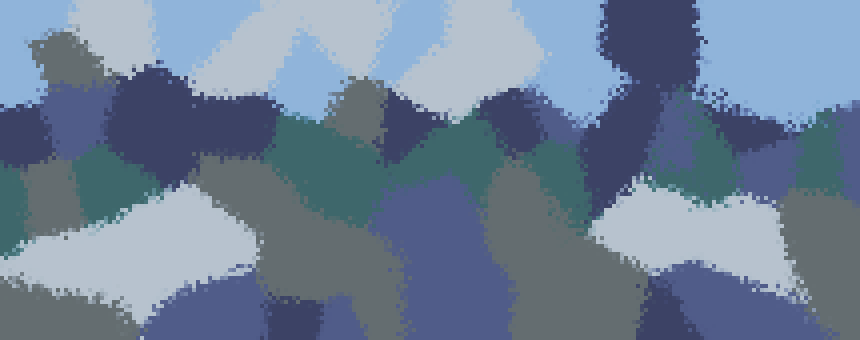

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([18, 4]) bbox
torch.Size([18])
IN IOUS max_iou
update_mesh tensor(0.4751, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


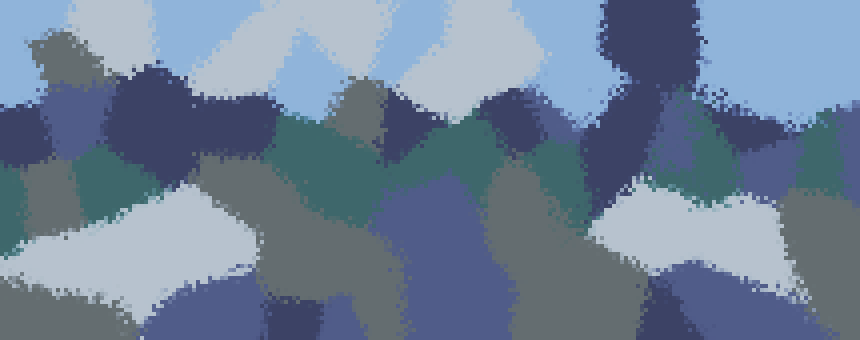

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([15, 4]) bbox
torch.Size([15])
IN IOUS max_iou
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
update_mesh tensor(0.4751, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


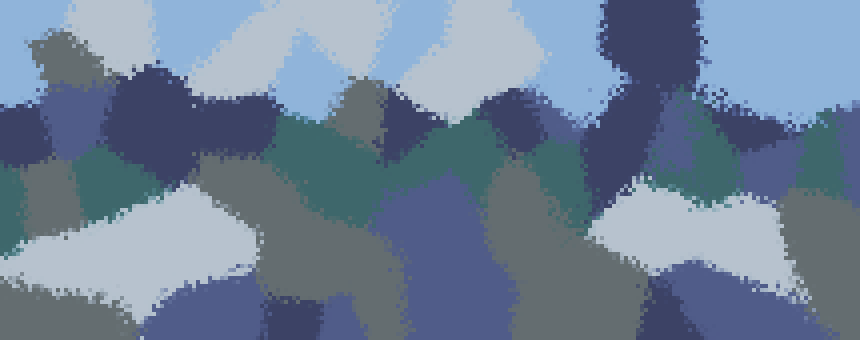

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([112, 4]) bbox
torch.Size([112])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
update_mesh tensor(0.4752, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


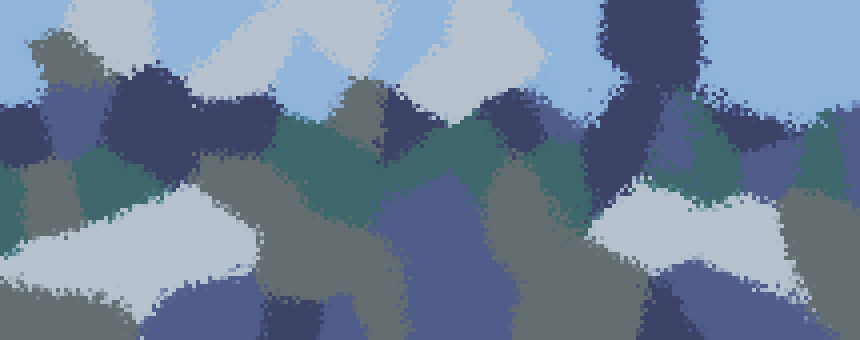

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([20, 4]) bbox
torch.Size([20])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
update_mesh tensor(0.4752, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


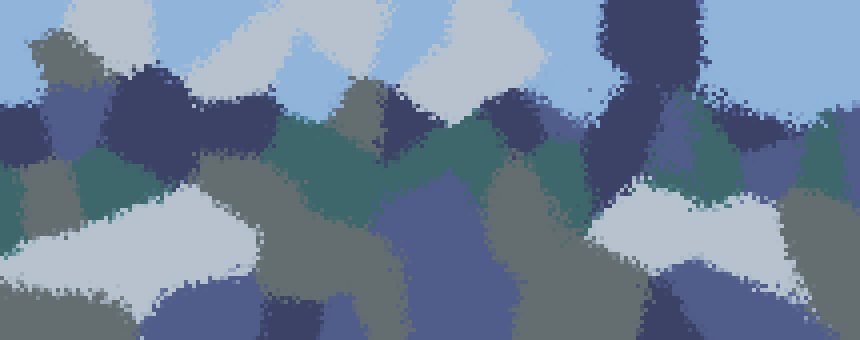

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([18, 4]) bbox
torch.Size([18])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
update_mesh tensor(0.4752, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


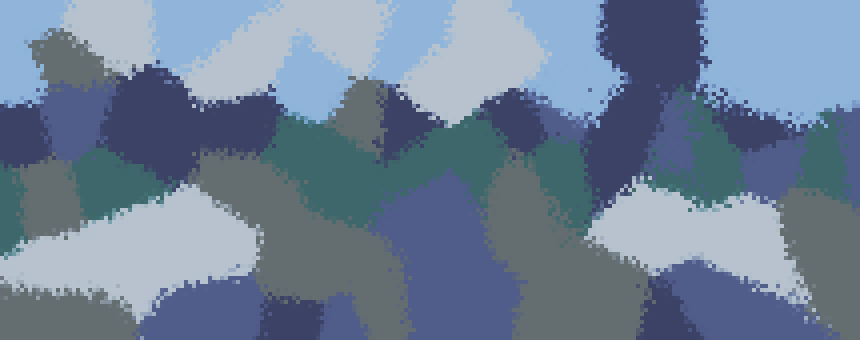

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
update_mesh tensor(0.4753, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


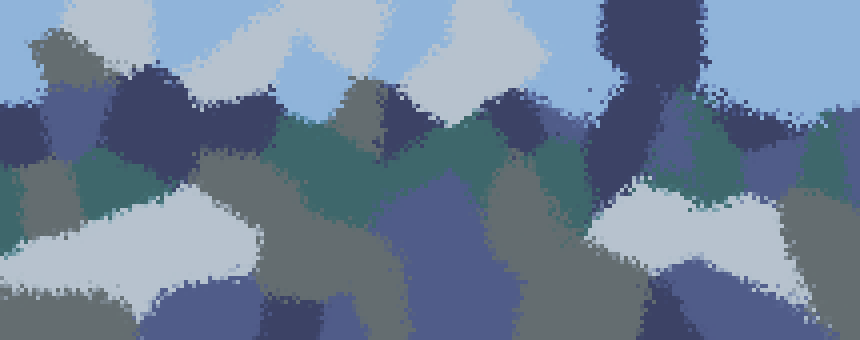

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([30, 4]) bbox
torch.Size([30])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([11, 4]) bbox
torch.Size([11])
IN IOUS max_iou
update_mesh tensor(0.4753, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


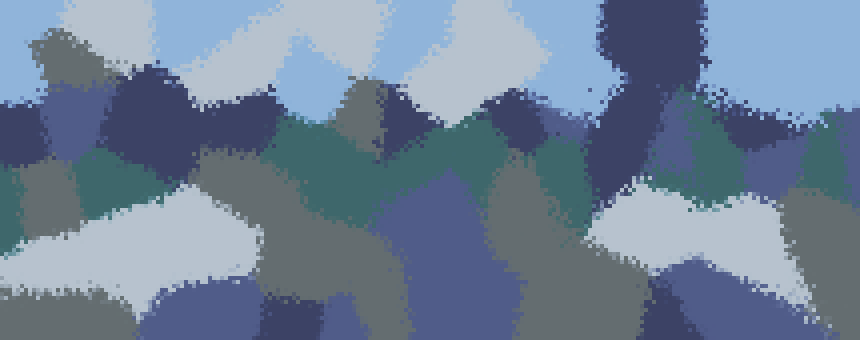

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([13, 4]) bbox
torch.Size([13])
IN IOUS max_iou
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
True
torch.Size([17, 4]) bbox
torch.Size([17])
IN IOUS max_iou
update_mesh tensor(0.4753, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


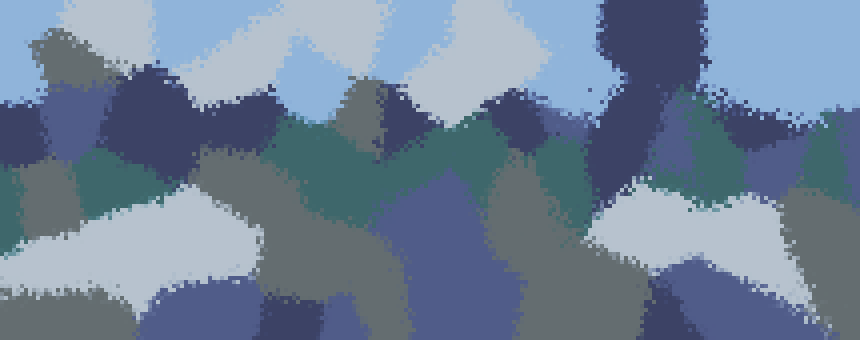

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
update_mesh tensor(0.4754, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


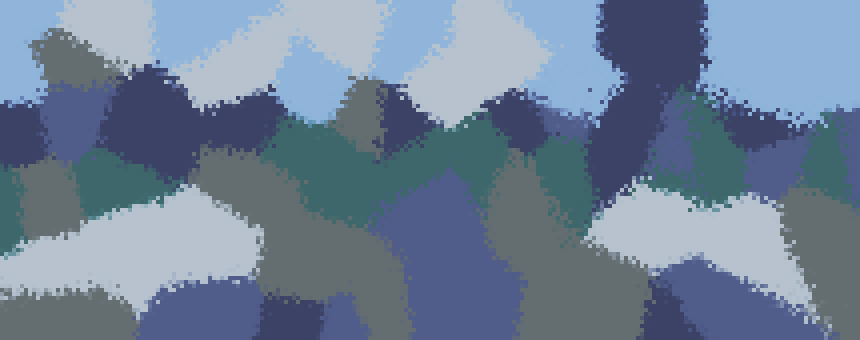

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
update_mesh tensor(0.4754, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


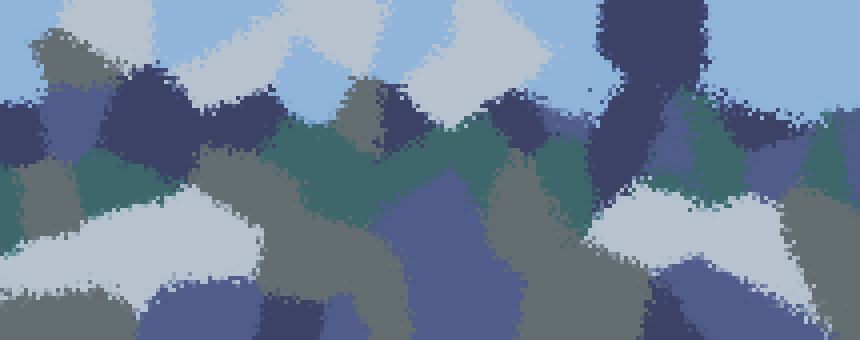

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([19, 4]) bbox
torch.Size([19])
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([49, 4]) bbox
torch.Size([49])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
update_mesh tensor(0.4754, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


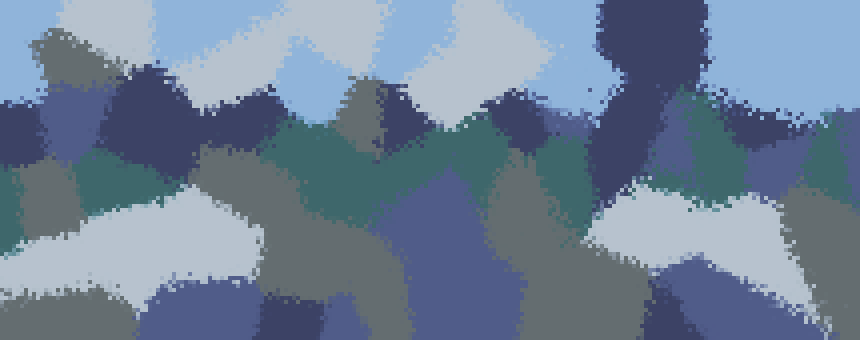

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([11, 4]) bbox
torch.Size([11])
IN IOUS max_iou
True
torch.Size([11, 4]) bbox
torch.Size([11])
IN IOUS max_iou
True
torch.Size([51, 4]) bbox
torch.Size([51])
IN IOUS max_iou
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
update_mesh tensor(0.4755, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


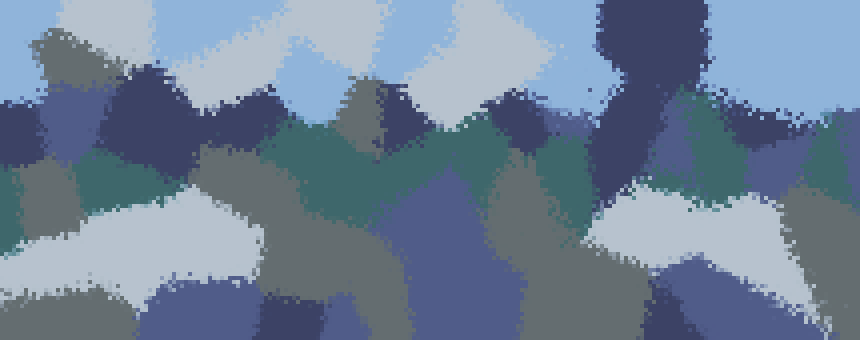

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
update_mesh tensor(0.4755, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


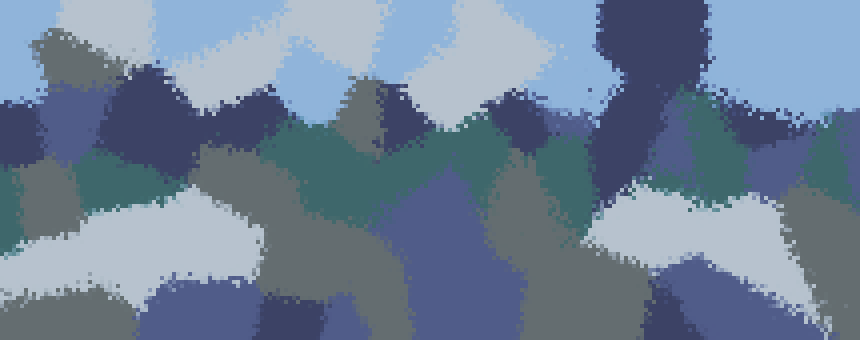

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([48, 4]) bbox
torch.Size([48])
IN IOUS max_iou
True
torch.Size([48, 4]) bbox
torch.Size([48])
IN IOUS max_iou
True
torch.Size([26, 4]) bbox
torch.Size([26])
IN IOUS max_iou
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
update_mesh tensor(0.4755, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


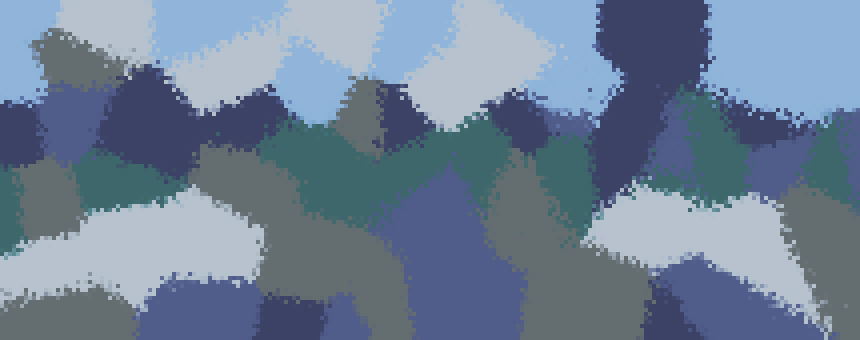

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([20, 4]) bbox
torch.Size([20])
IN IOUS max_iou
True
torch.Size([22, 4]) bbox
torch.Size([22])
IN IOUS max_iou
update_mesh tensor(0.4756, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


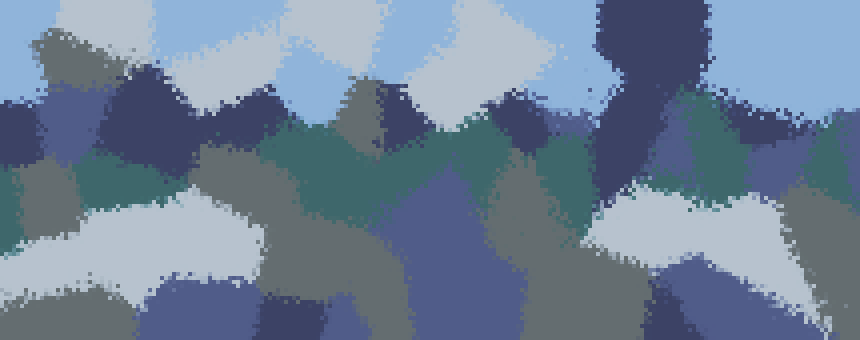

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([57, 4]) bbox
torch.Size([57])
IN IOUS max_iou
True
torch.Size([18, 4]) bbox
torch.Size([18])
IN IOUS max_iou
True
torch.Size([14, 4]) bbox
torch.Size([14])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
update_mesh tensor(0.4756, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


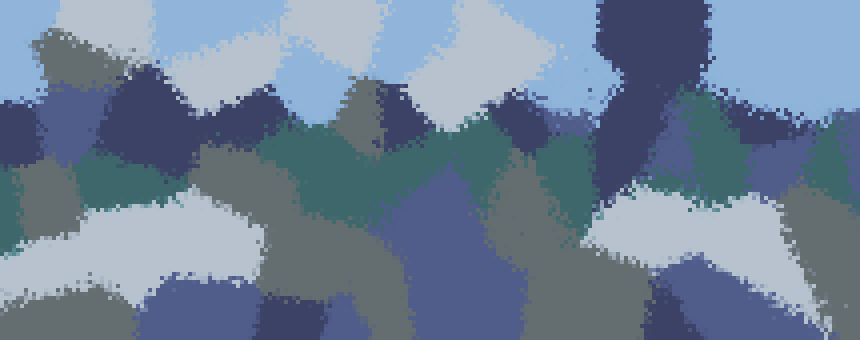

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
True
torch.Size([32, 4]) bbox
torch.Size([32])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
update_mesh tensor(0.4756, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


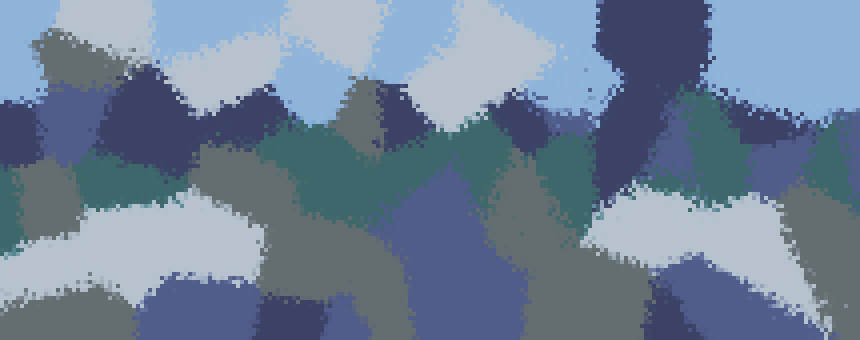

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([20, 4]) bbox
torch.Size([20])
IN IOUS max_iou
update_mesh tensor(0.4756, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


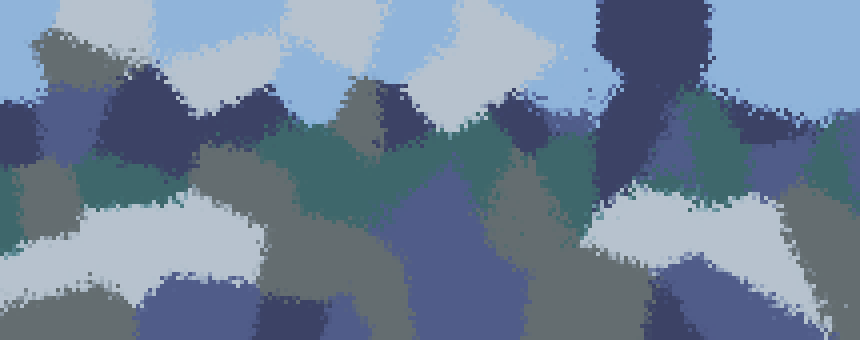

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([27, 4]) bbox
torch.Size([27])
IN IOUS max_iou
True
torch.Size([19, 4]) bbox
torch.Size([19])
IN IOUS max_iou
update_mesh tensor(0.4756, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


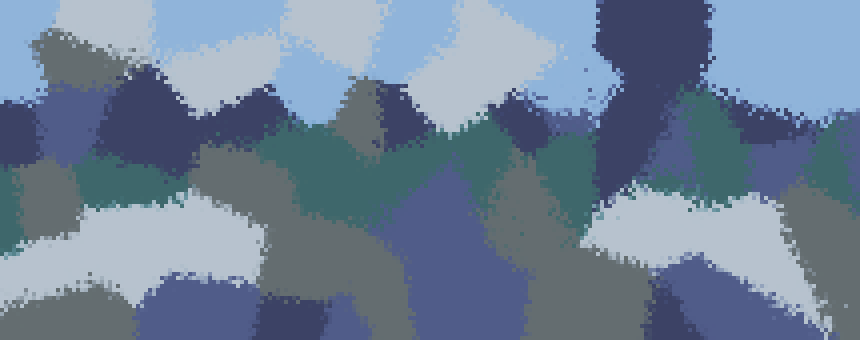

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([65, 4]) bbox
torch.Size([65])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
update_mesh tensor(0.4757, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


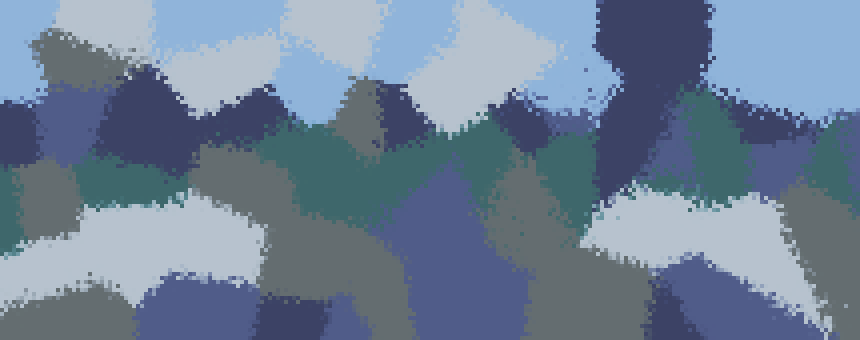

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
update_mesh tensor(0.4757, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


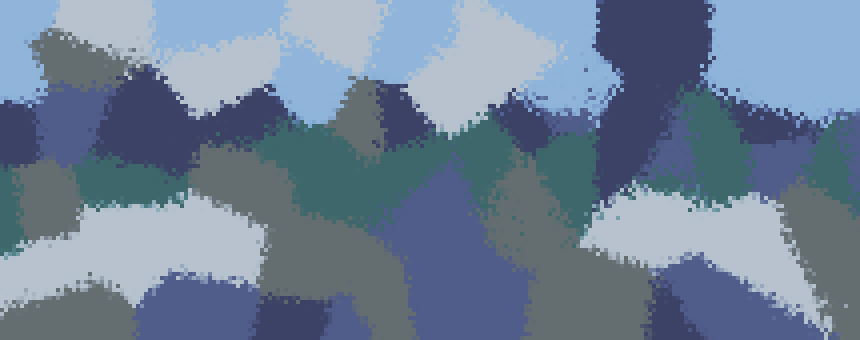

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
update_mesh tensor(0.4757, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


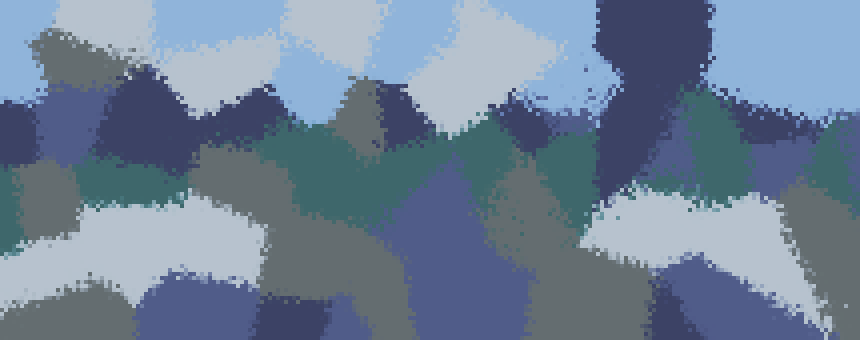

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
update_mesh tensor(0.4757, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


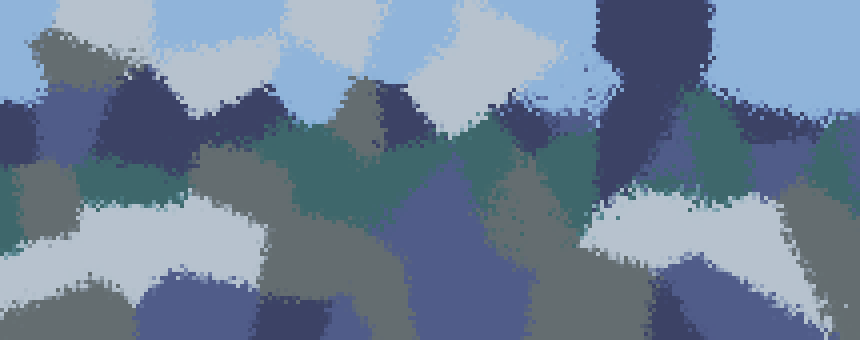

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([17, 4]) bbox
torch.Size([17])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
update_mesh tensor(0.4758, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


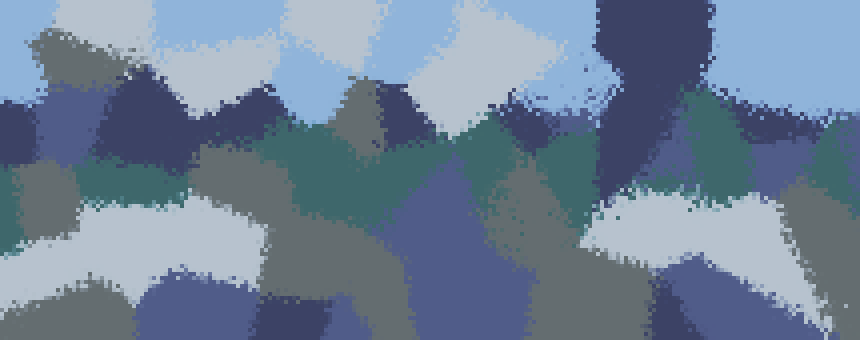

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([30, 4]) bbox
torch.Size([30])
IN IOUS max_iou
True
torch.Size([15, 4]) bbox
torch.Size([15])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
update_mesh tensor(0.4758, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


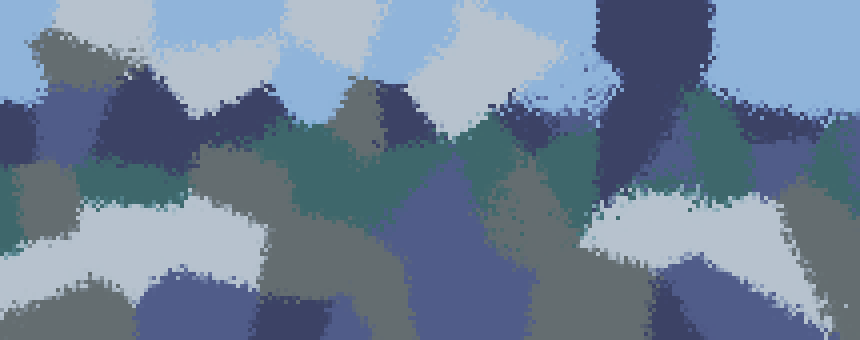

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([21, 4]) bbox
torch.Size([21])
IN IOUS max_iou
update_mesh tensor(0.4758, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


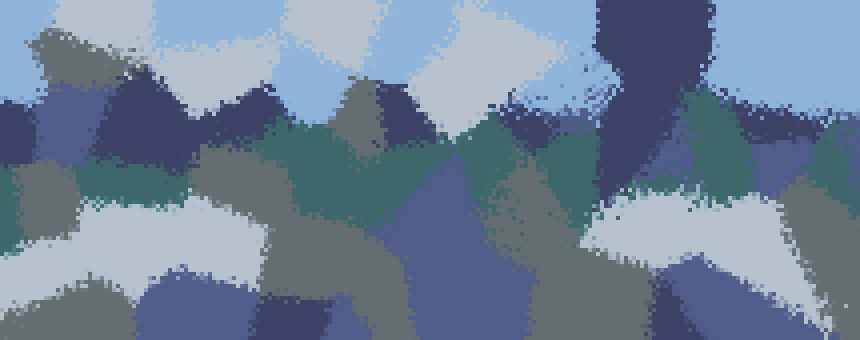

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([15, 4]) bbox
torch.Size([15])
IN IOUS max_iou
True
torch.Size([27, 4]) bbox
torch.Size([27])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
update_mesh tensor(0.4758, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


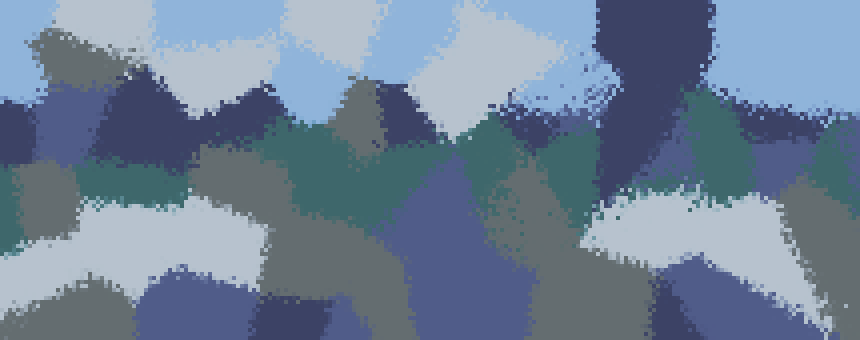

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([23, 4]) bbox
torch.Size([23])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([13, 4]) bbox
torch.Size([13])
IN IOUS max_iou
update_mesh tensor(0.4759, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


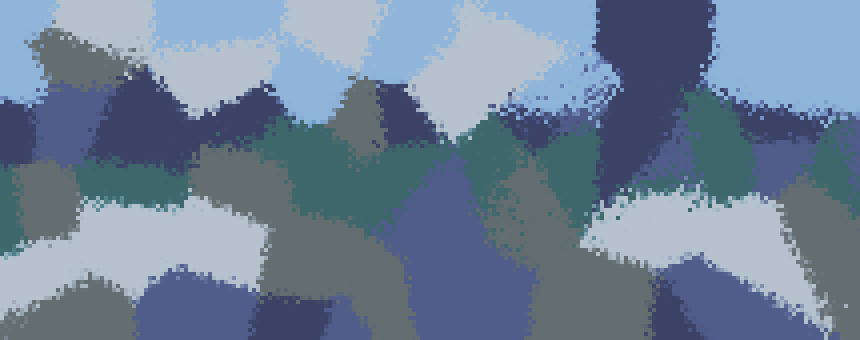

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([14, 4]) bbox
torch.Size([14])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
update_mesh tensor(0.4759, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


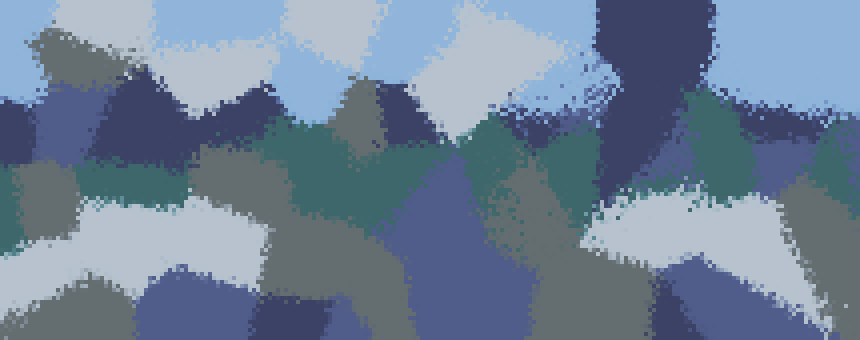

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([70, 4]) bbox
torch.Size([70])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
update_mesh tensor(0.4759, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


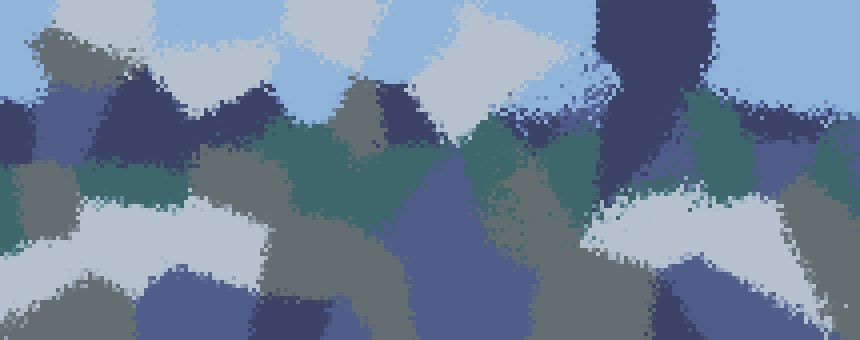

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([44, 4]) bbox
torch.Size([44])
IN IOUS max_iou
update_mesh tensor(0.4759, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


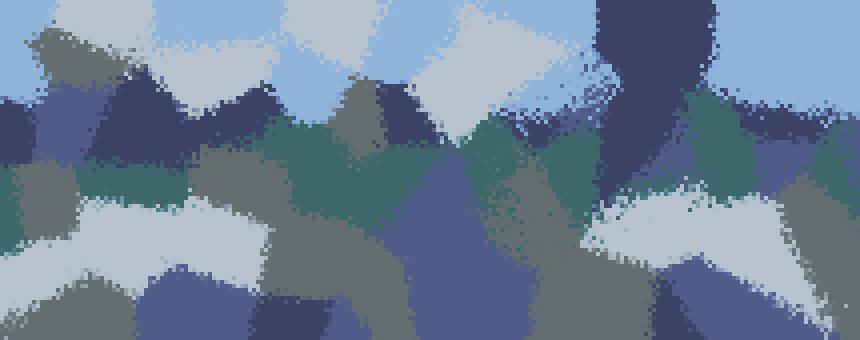

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([22, 4]) bbox
torch.Size([22])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
update_mesh tensor(0.4759, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


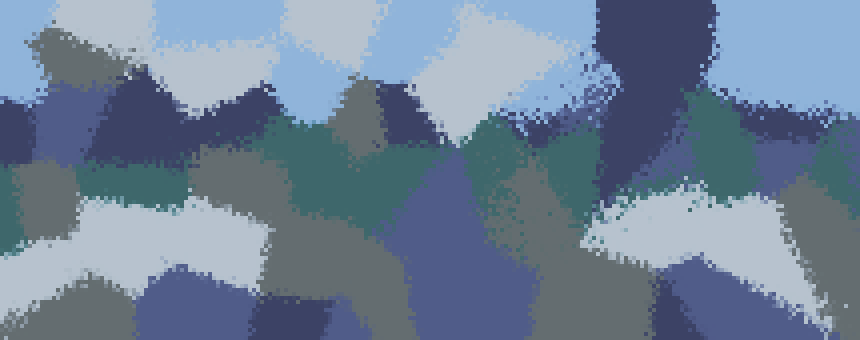

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([22, 4]) bbox
torch.Size([22])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
update_mesh tensor(0.4760, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


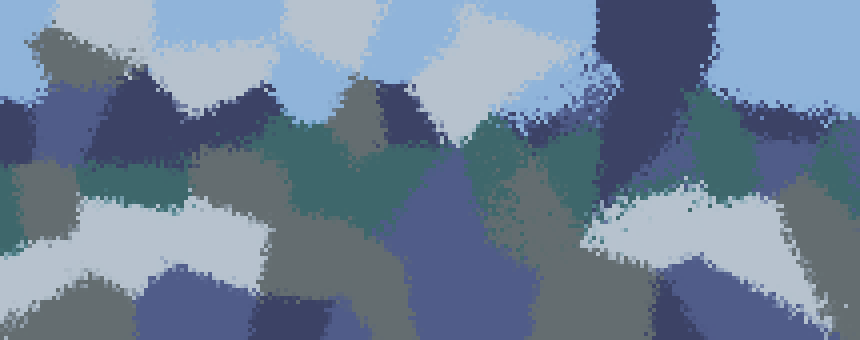

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([26, 4]) bbox
torch.Size([26])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
update_mesh tensor(0.4760, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


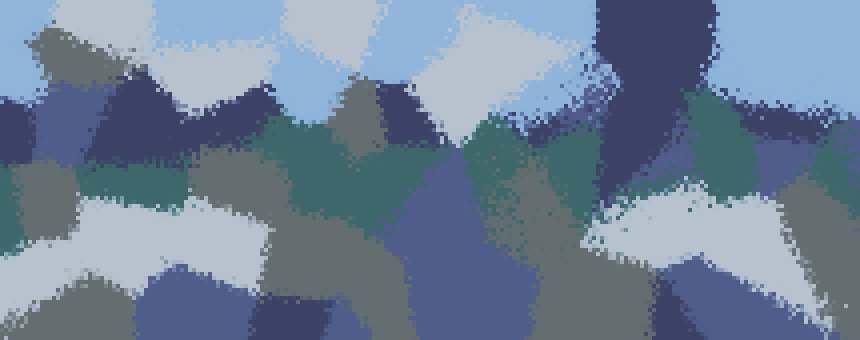

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
True
torch.Size([20, 4]) bbox
torch.Size([20])
IN IOUS max_iou
update_mesh tensor(0.4760, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


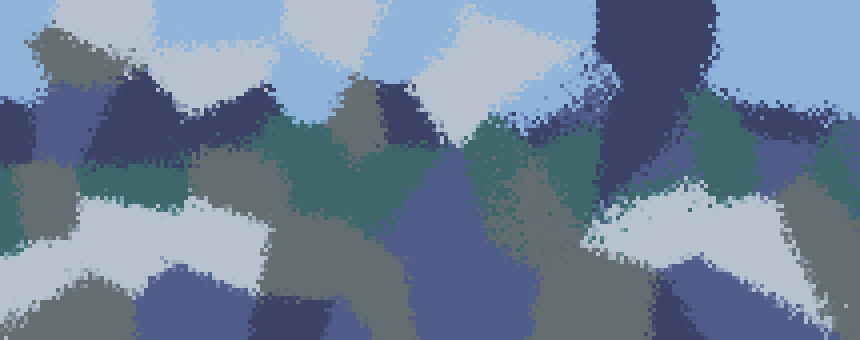

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([55, 4]) bbox
torch.Size([55])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
update_mesh tensor(0.4760, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


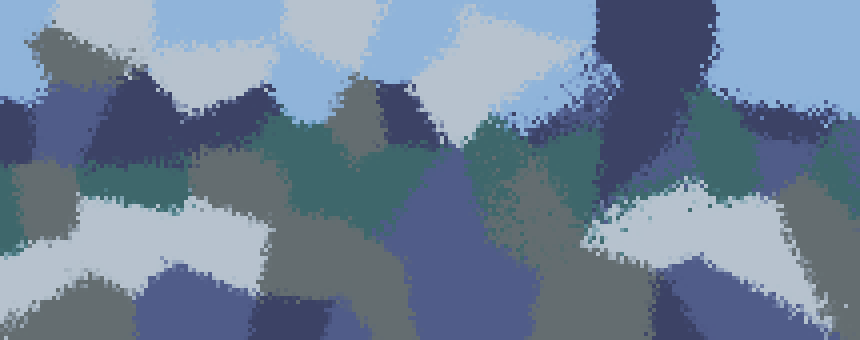

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
update_mesh tensor(0.4760, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


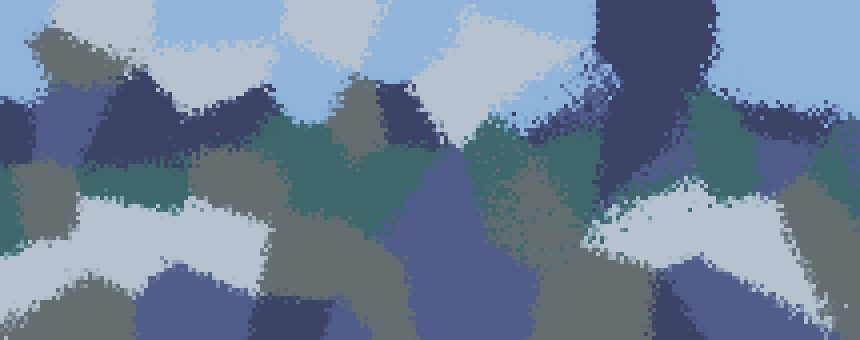

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([63, 4]) bbox
torch.Size([63])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
update_mesh tensor(0.4760, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


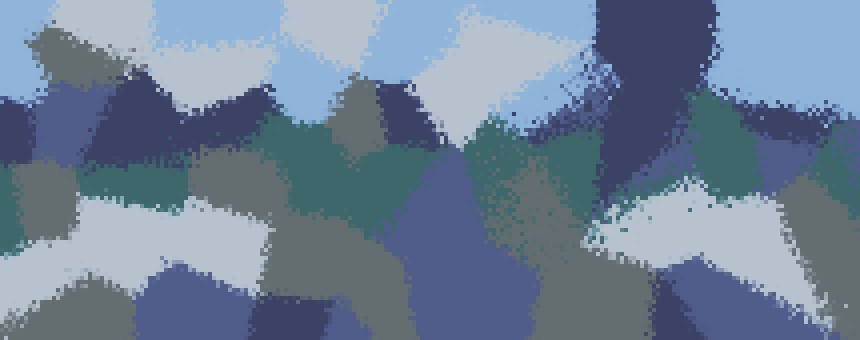

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
update_mesh tensor(0.4760, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


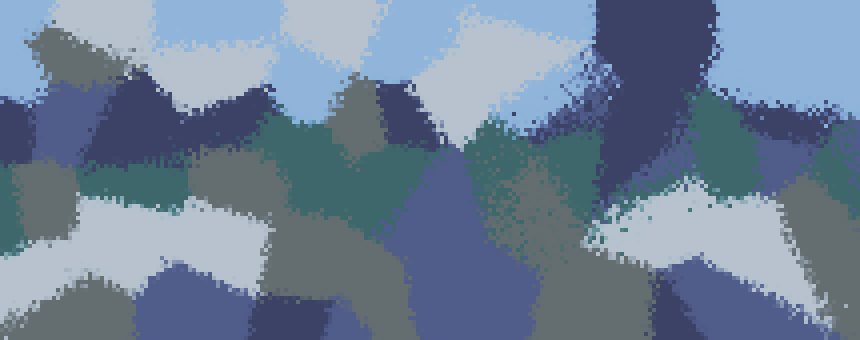

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([19, 4]) bbox
torch.Size([19])
IN IOUS max_iou
update_mesh tensor(0.4761, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


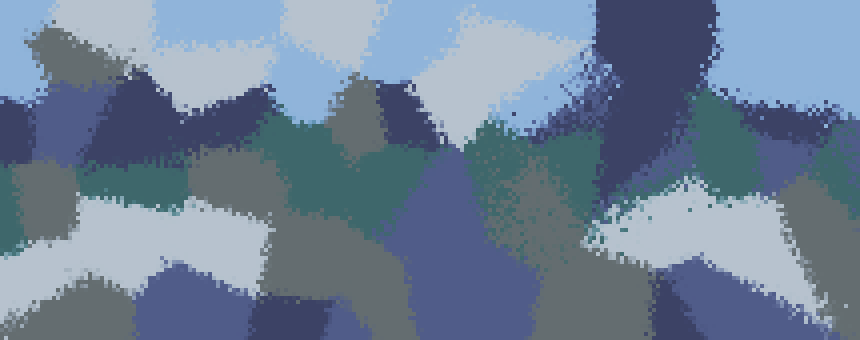

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([21, 4]) bbox
torch.Size([21])
IN IOUS max_iou
update_mesh tensor(0.4761, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


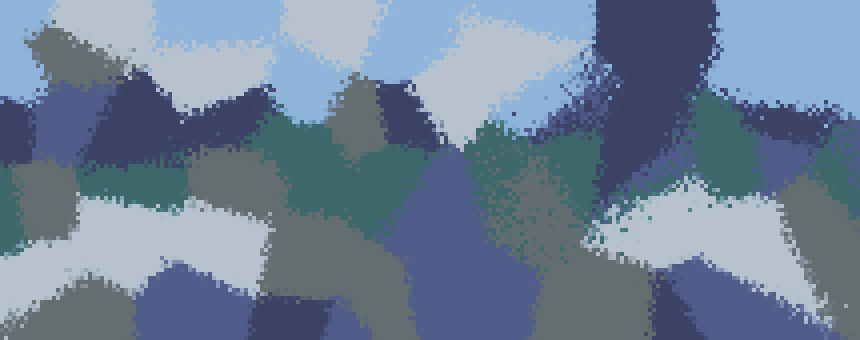

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
update_mesh tensor(0.4761, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


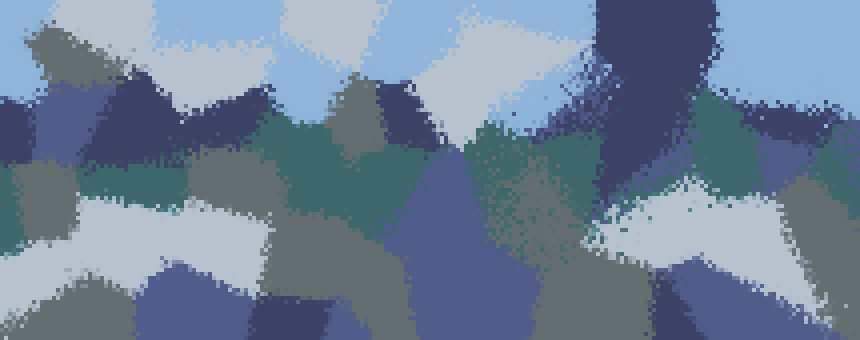

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([19, 4]) bbox
torch.Size([19])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
update_mesh tensor(0.4761, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


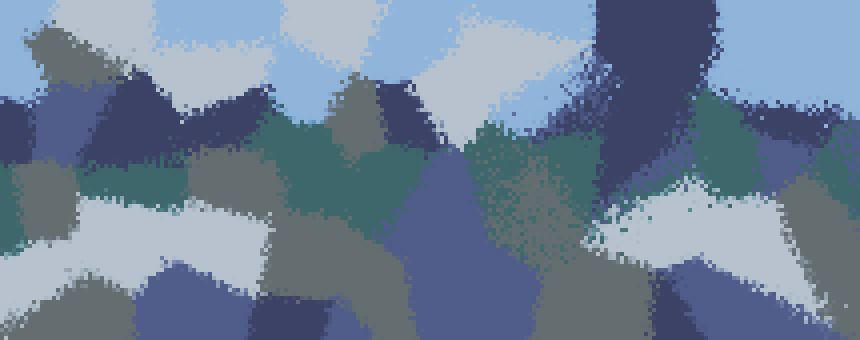

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
update_mesh tensor(0.4761, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


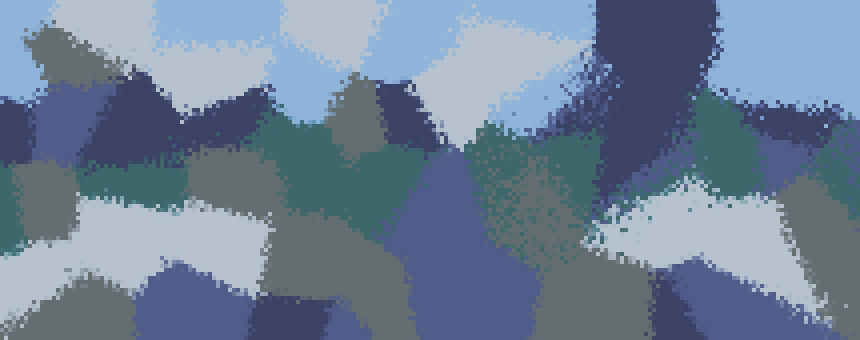

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
update_mesh tensor(0.4761, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


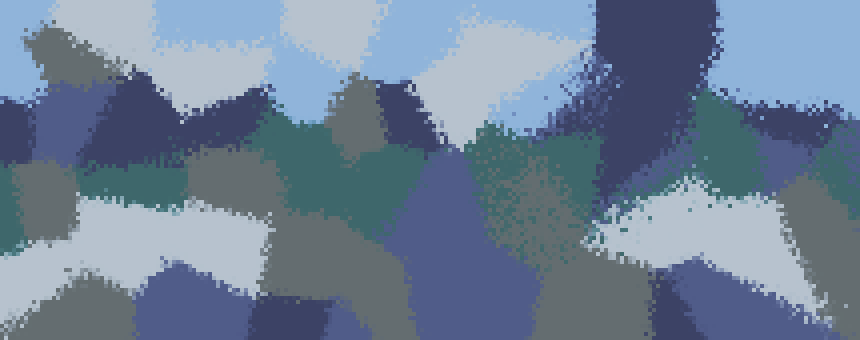

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
update_mesh tensor(0.4761, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


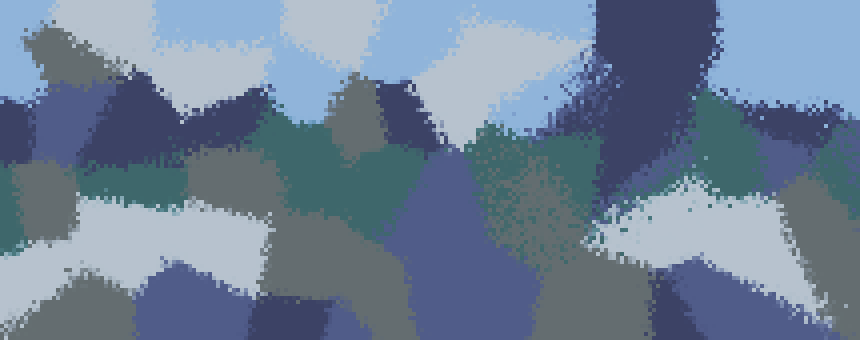

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([14, 4]) bbox
torch.Size([14])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
update_mesh tensor(0.4761, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


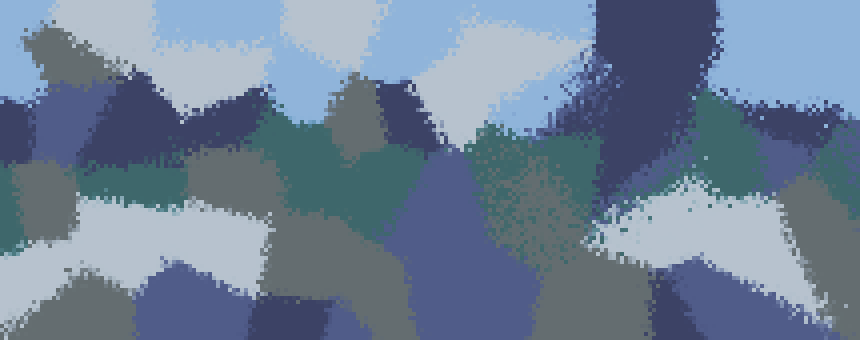

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([41, 4]) bbox
torch.Size([41])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
update_mesh tensor(0.4761, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


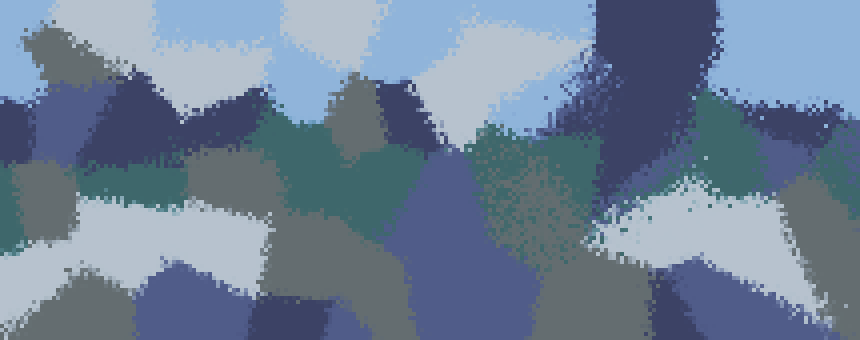

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([11, 4]) bbox
torch.Size([11])
IN IOUS max_iou
True
torch.Size([26, 4]) bbox
torch.Size([26])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
update_mesh tensor(0.4761, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


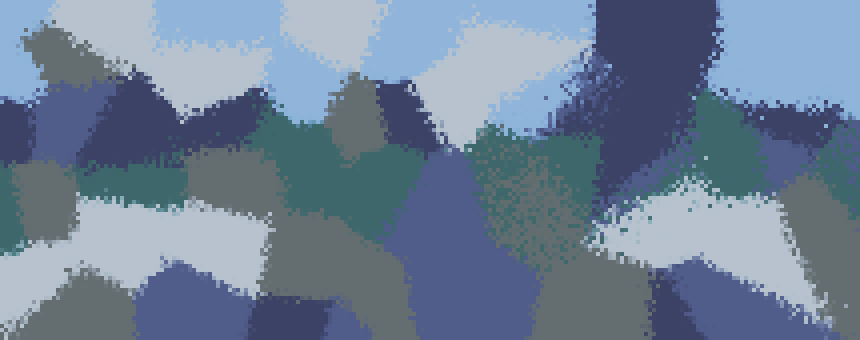

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
update_mesh tensor(0.4761, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


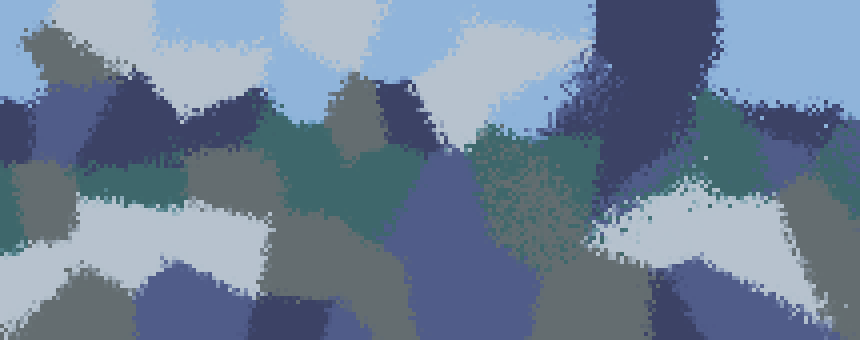

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([20, 4]) bbox
torch.Size([20])
IN IOUS max_iou
update_mesh tensor(0.4762, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


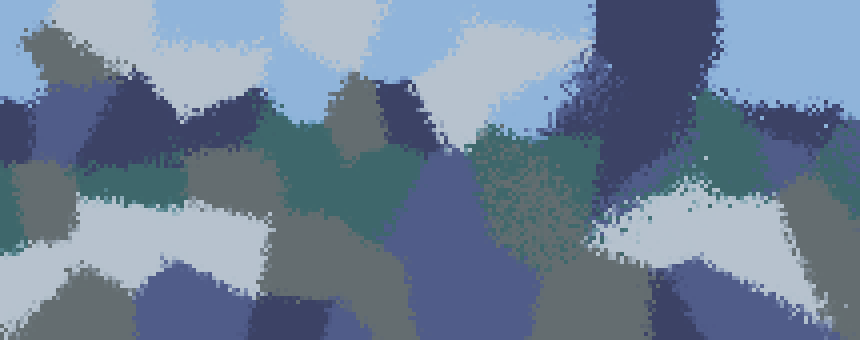

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([37, 4]) bbox
torch.Size([37])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
update_mesh tensor(0.4762, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


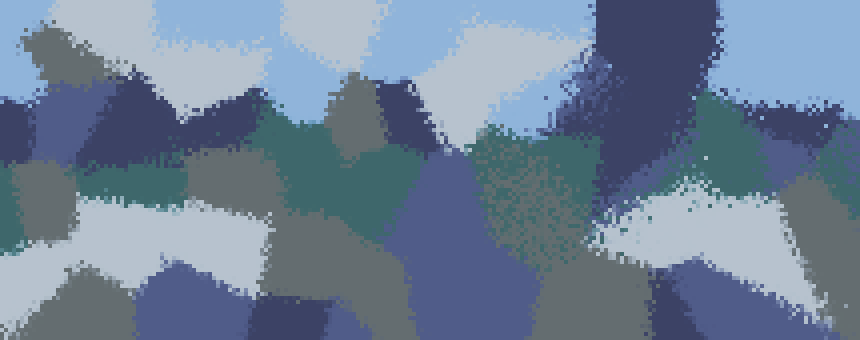

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([24, 4]) bbox
torch.Size([24])
IN IOUS max_iou
update_mesh tensor(0.4762, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


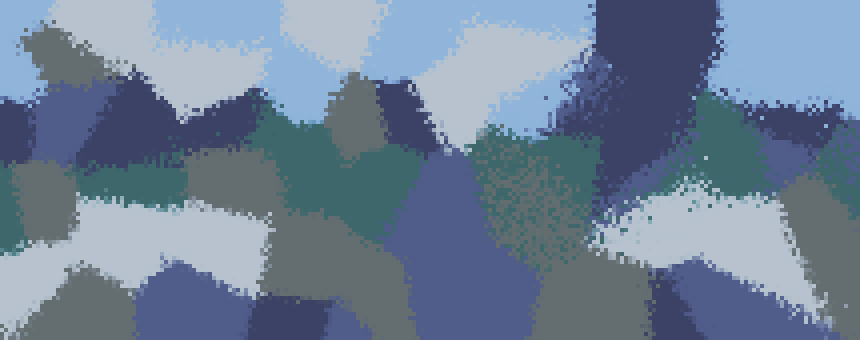

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([23, 4]) bbox
torch.Size([23])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
update_mesh tensor(0.4762, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


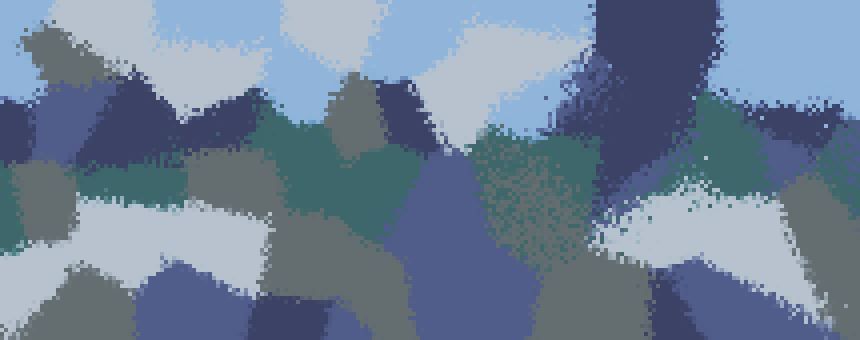

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([24, 4]) bbox
torch.Size([24])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([14, 4]) bbox
torch.Size([14])
IN IOUS max_iou
update_mesh tensor(0.4762, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


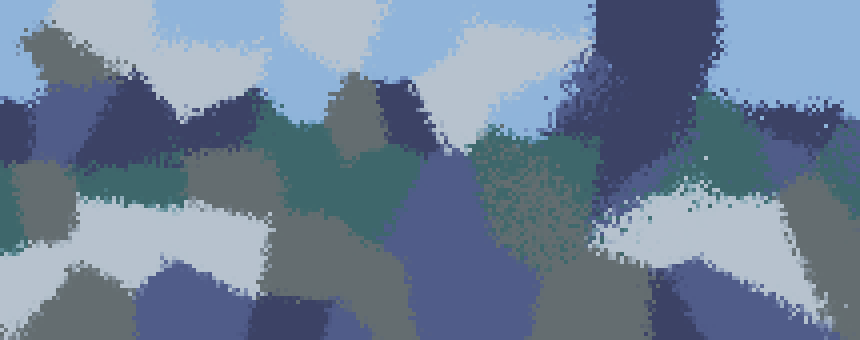

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
update_mesh tensor(0.4763, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


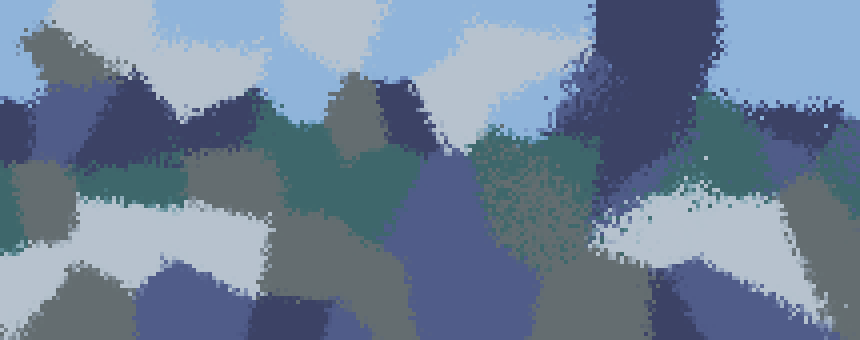

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([20, 4]) bbox
torch.Size([20])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
update_mesh tensor(0.4763, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


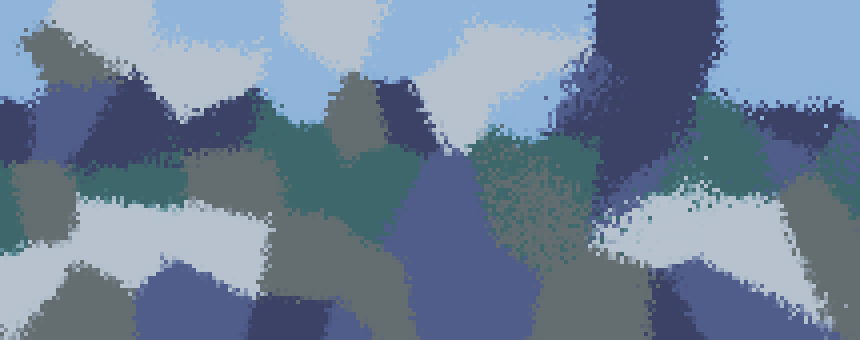

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
update_mesh tensor(0.4763, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


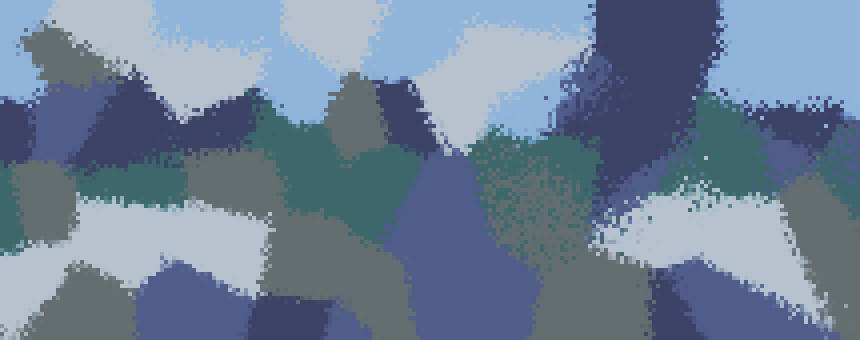

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([21, 4]) bbox
torch.Size([21])
IN IOUS max_iou
True
torch.Size([19, 4]) bbox
torch.Size([19])
IN IOUS max_iou
update_mesh tensor(0.4763, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


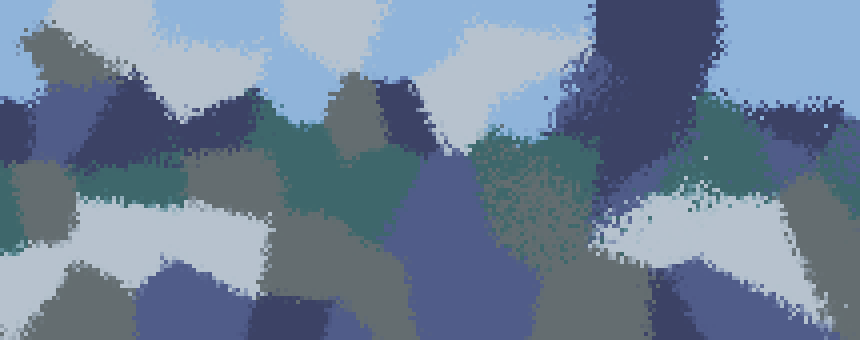

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([24, 4]) bbox
torch.Size([24])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([47, 4]) bbox
torch.Size([47])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
update_mesh tensor(0.4763, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


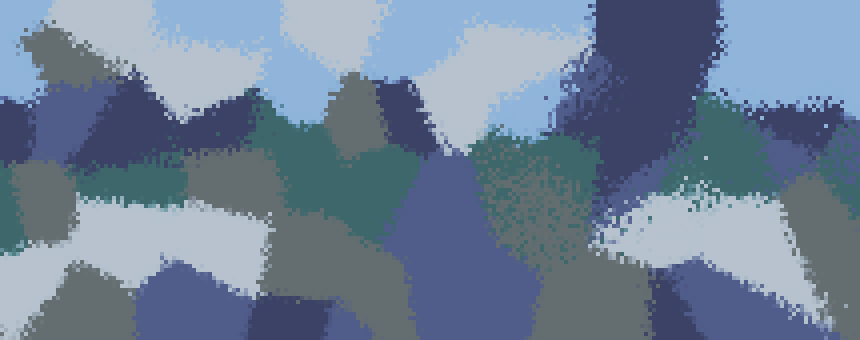

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([19, 4]) bbox
torch.Size([19])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
update_mesh tensor(0.4764, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


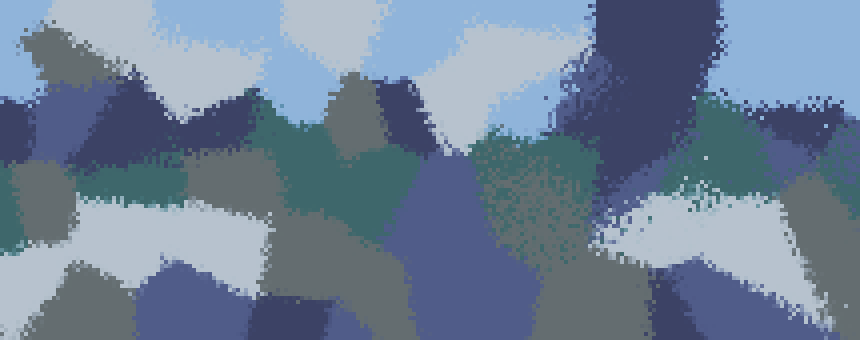

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([42, 4]) bbox
torch.Size([42])
IN IOUS max_iou
True
torch.Size([20, 4]) bbox
torch.Size([20])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
update_mesh tensor(0.4764, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


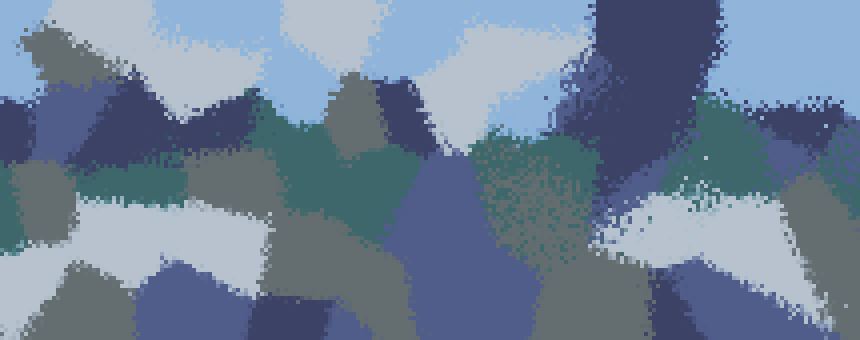

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([30, 4]) bbox
torch.Size([30])
IN IOUS max_iou
True
torch.Size([36, 4]) bbox
torch.Size([36])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
update_mesh tensor(0.4764, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


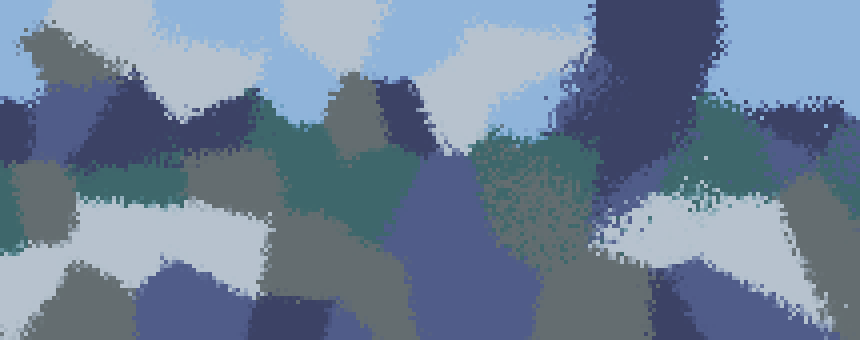

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
update_mesh tensor(0.4764, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


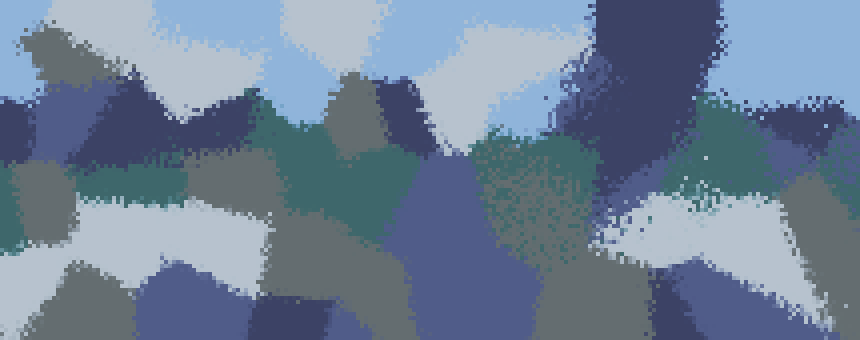

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
update_mesh tensor(0.4764, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


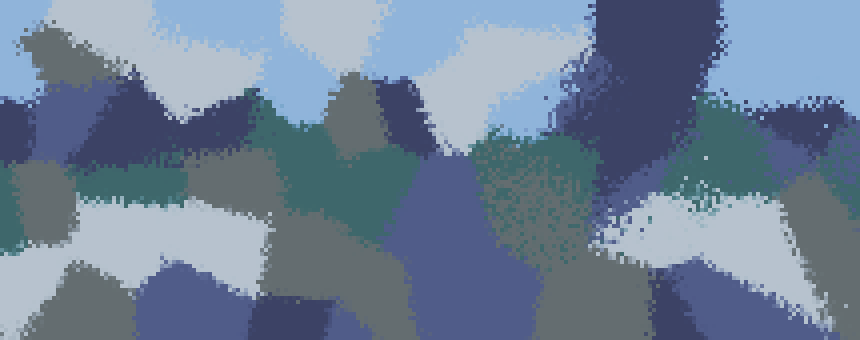

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


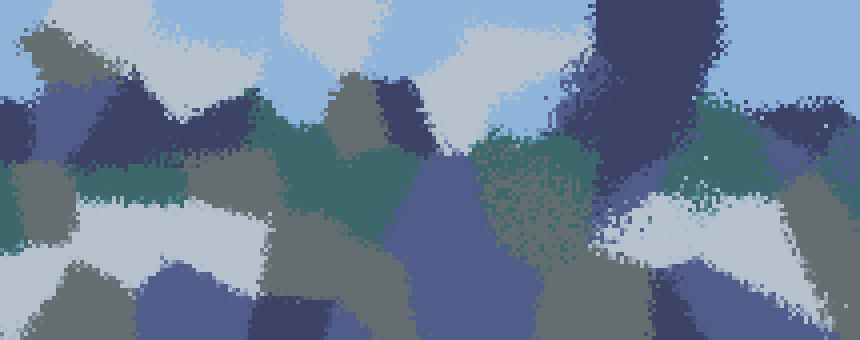

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([14, 4]) bbox
torch.Size([14])
IN IOUS max_iou
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


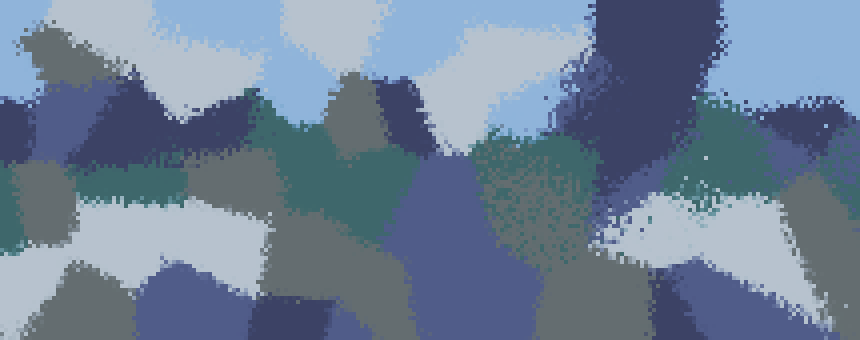

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([22, 4]) bbox
torch.Size([22])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


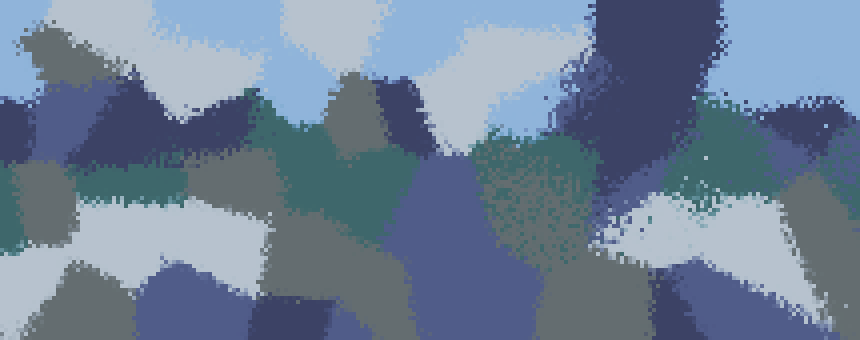

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
True
torch.Size([29, 4]) bbox
torch.Size([29])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


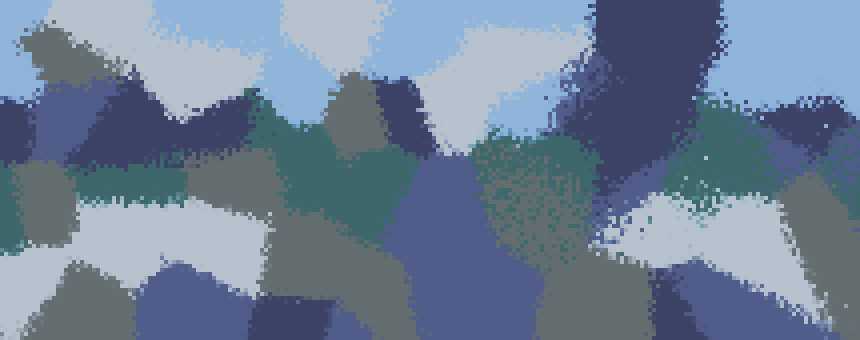

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([20, 4]) bbox
torch.Size([20])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


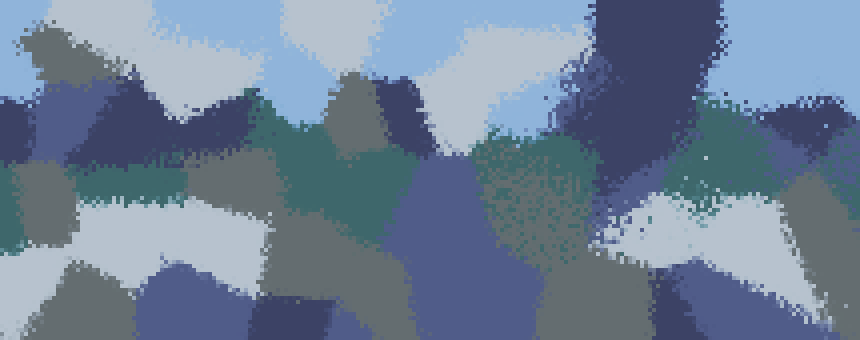

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([40, 4]) bbox
torch.Size([40])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


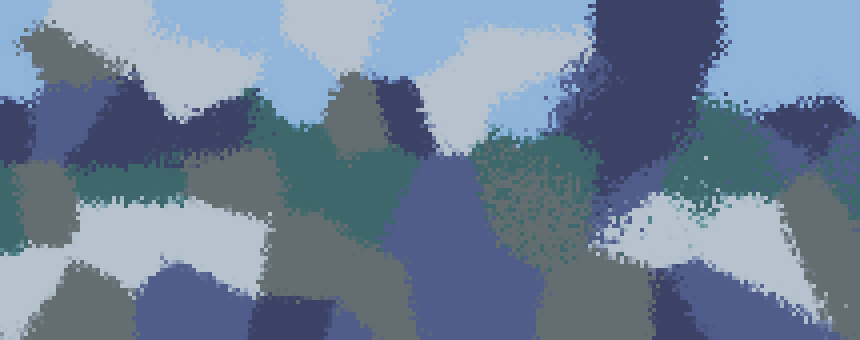

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([41, 4]) bbox
torch.Size([41])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


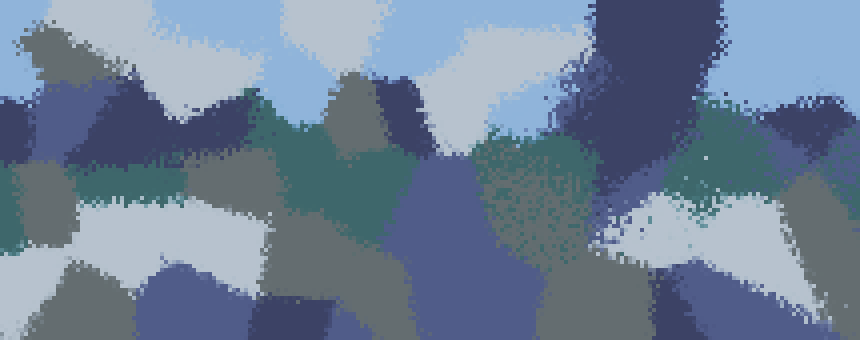

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([17, 4]) bbox
torch.Size([17])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


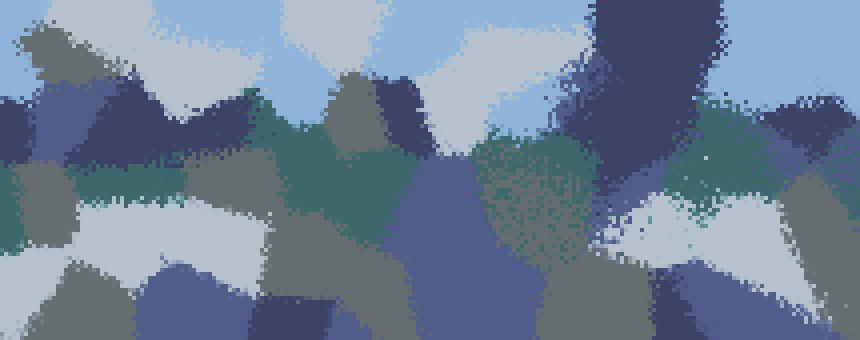

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([18, 4]) bbox
torch.Size([18])
IN IOUS max_iou
True
torch.Size([13, 4]) bbox
torch.Size([13])
IN IOUS max_iou
True
torch.Size([34, 4]) bbox
torch.Size([34])
IN IOUS max_iou
True
torch.Size([22, 4]) bbox
torch.Size([22])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


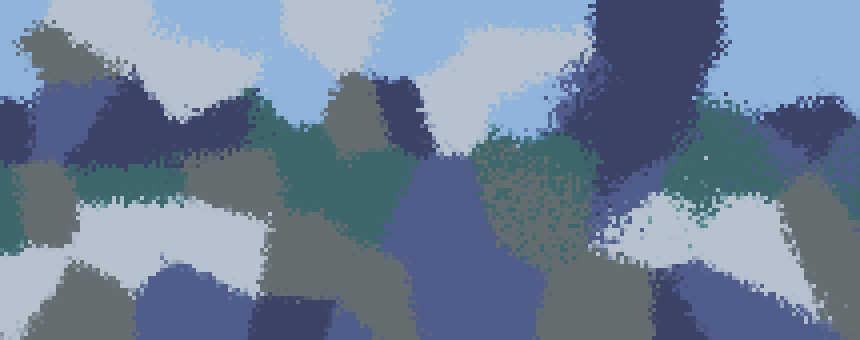

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([13, 4]) bbox
torch.Size([13])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([21, 4]) bbox
torch.Size([21])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


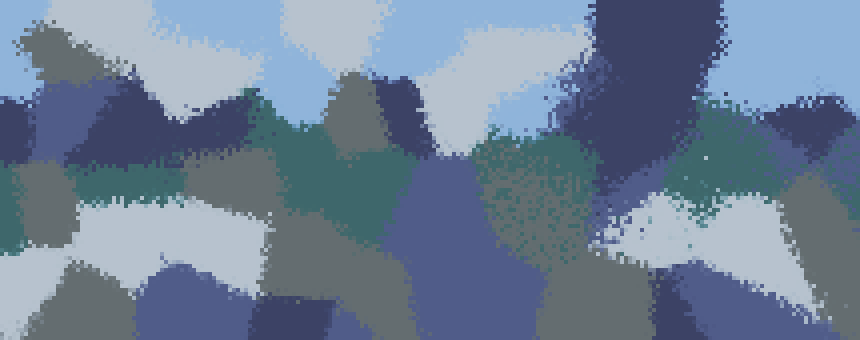

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


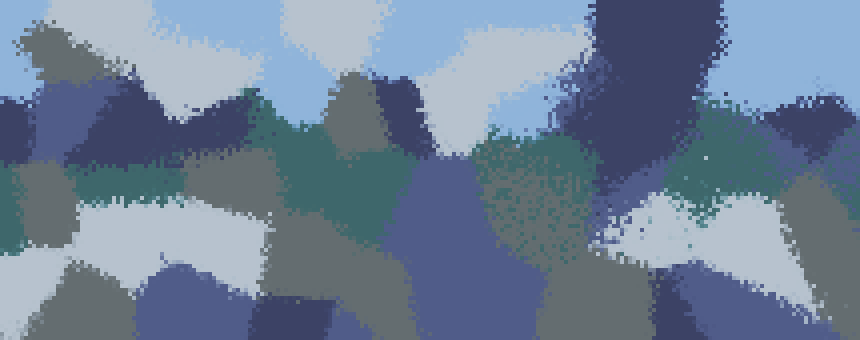

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([19, 4]) bbox
torch.Size([19])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([11, 4]) bbox
torch.Size([11])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


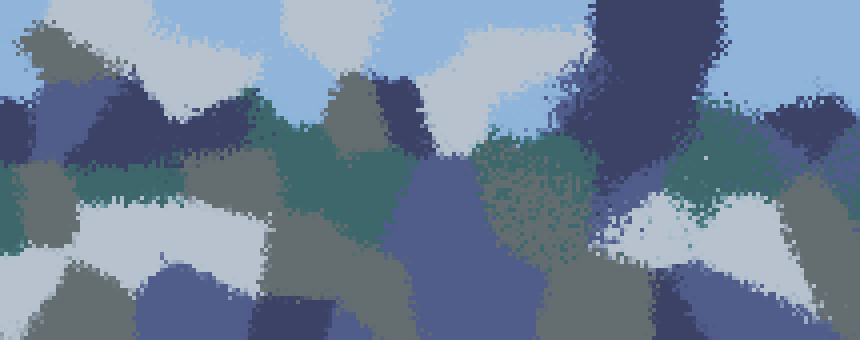

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([19, 4]) bbox
torch.Size([19])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


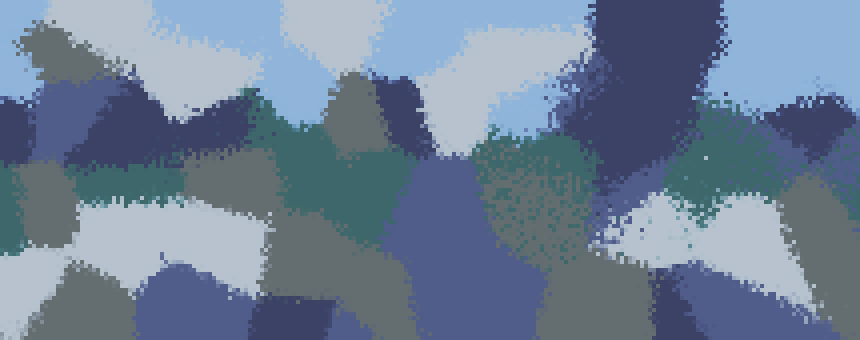

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([45, 4]) bbox
torch.Size([45])
IN IOUS max_iou
True
torch.Size([15, 4]) bbox
torch.Size([15])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


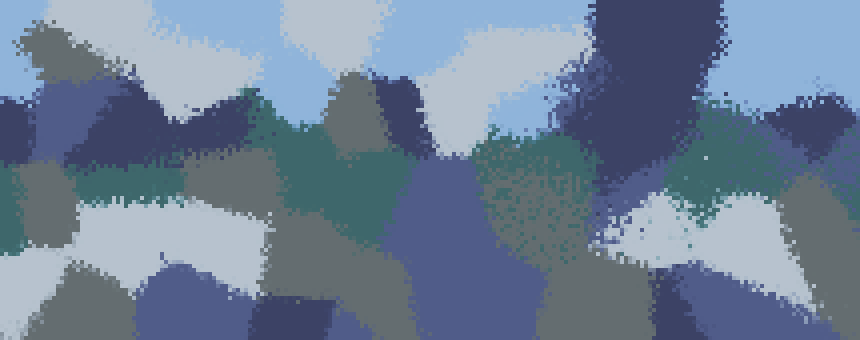

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([13, 4]) bbox
torch.Size([13])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([20, 4]) bbox
torch.Size([20])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


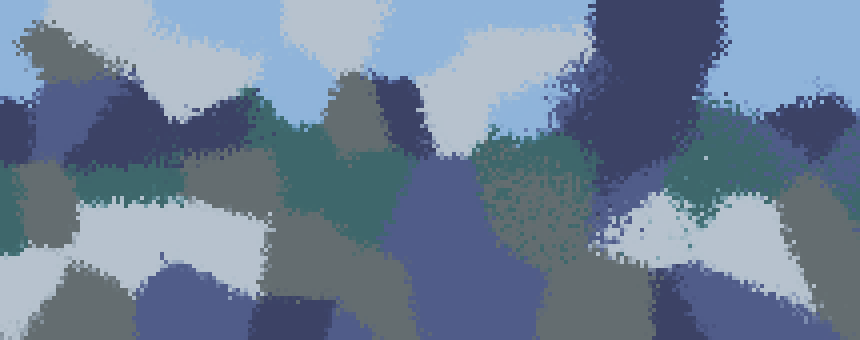

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([1, 4]) bbox
torch.Size([1])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


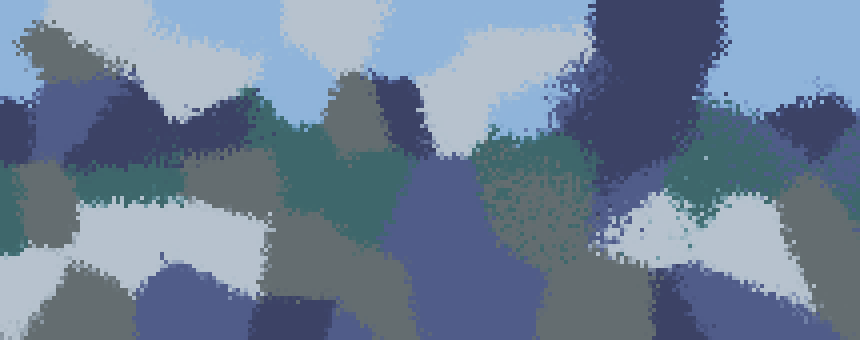

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


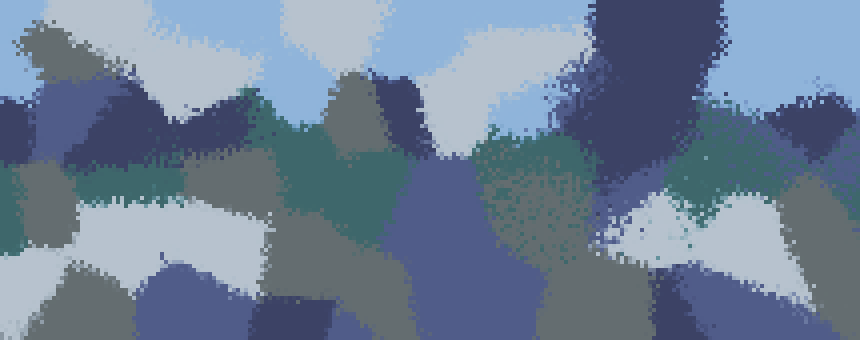

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([12, 4]) bbox
torch.Size([12])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([9, 4]) bbox
torch.Size([9])
IN IOUS max_iou
True
torch.Size([17, 4]) bbox
torch.Size([17])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


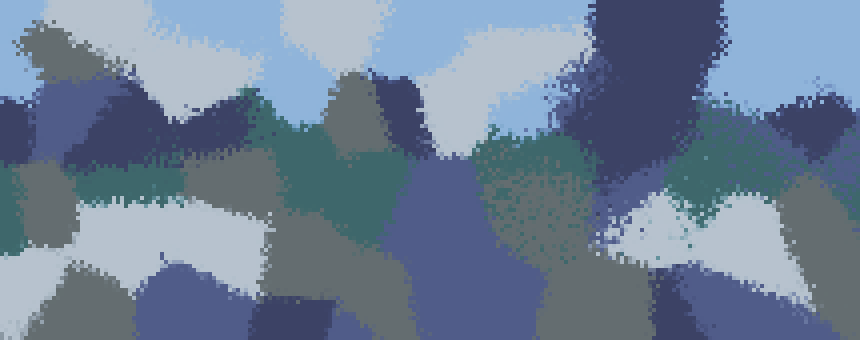

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([18, 4]) bbox
torch.Size([18])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


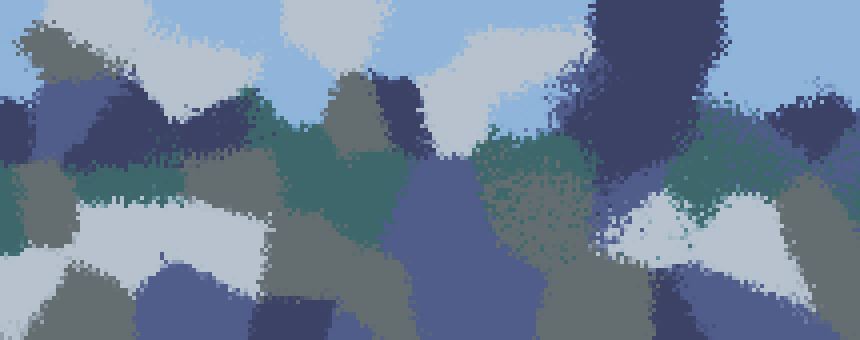

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([16, 4]) bbox
torch.Size([16])
IN IOUS max_iou
True
torch.Size([15, 4]) bbox
torch.Size([15])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


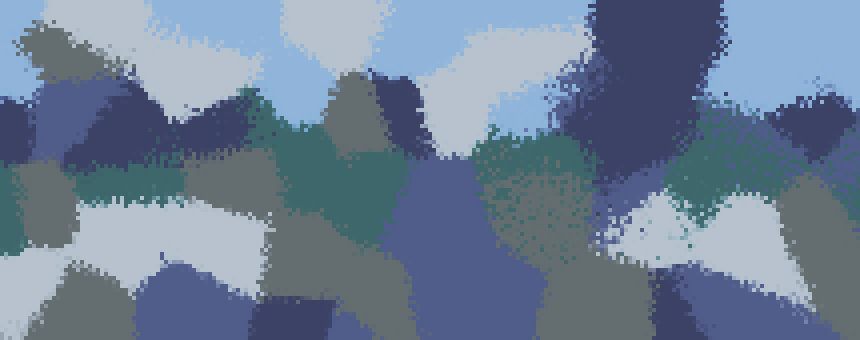

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([7, 4]) bbox
torch.Size([7])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


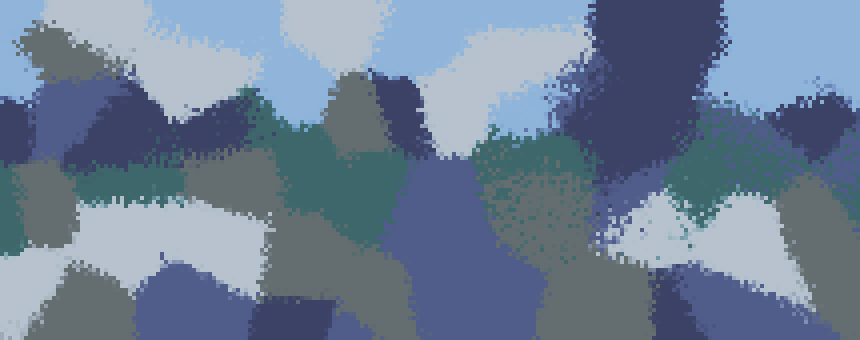

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


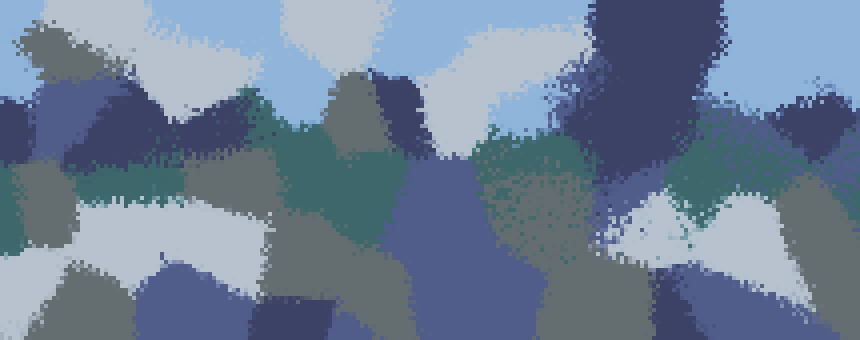

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([36, 4]) bbox
torch.Size([36])
IN IOUS max_iou
True
torch.Size([26, 4]) bbox
torch.Size([26])
IN IOUS max_iou
True
torch.Size([19, 4]) bbox
torch.Size([19])
IN IOUS max_iou
True
torch.Size([27, 4]) bbox
torch.Size([27])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


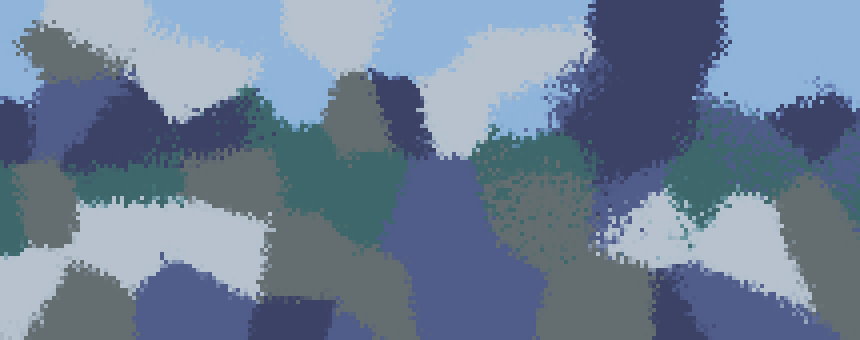

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([11, 4]) bbox
torch.Size([11])
IN IOUS max_iou
update_mesh tensor(0.4766, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


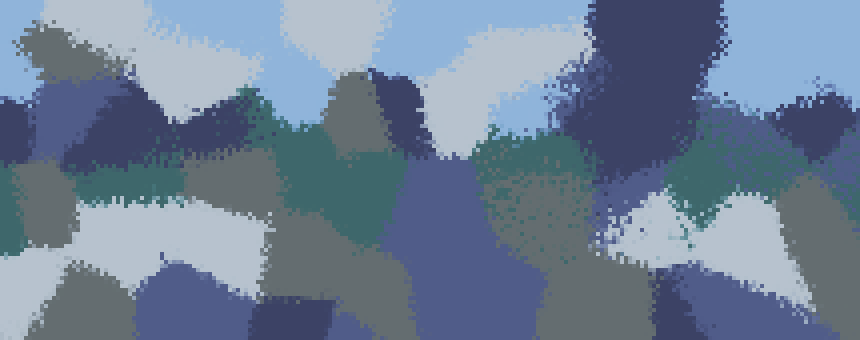

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([3, 4]) bbox
torch.Size([3])
IN IOUS max_iou
True
torch.Size([27, 4]) bbox
torch.Size([27])
IN IOUS max_iou
True
torch.Size([25, 4]) bbox
torch.Size([25])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


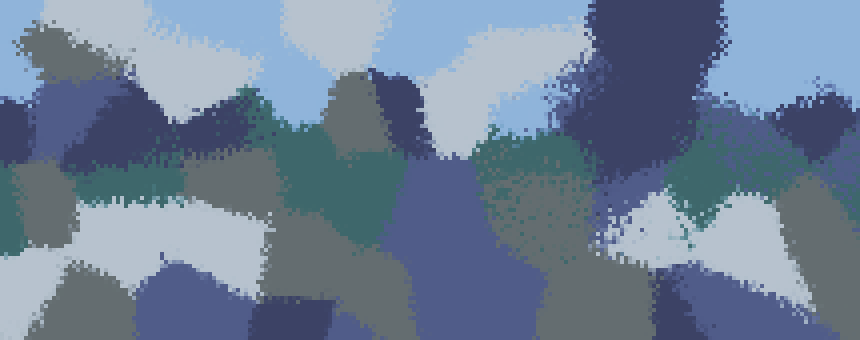

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([6, 4]) bbox
torch.Size([6])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


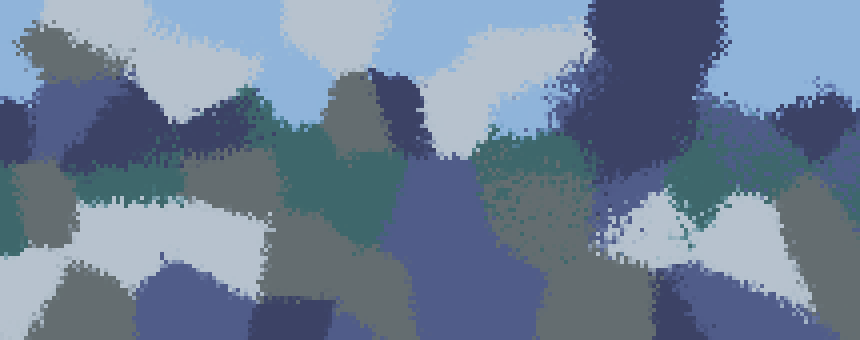

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([32, 4]) bbox
torch.Size([32])
IN IOUS max_iou
True
torch.Size([39, 4]) bbox
torch.Size([39])
IN IOUS max_iou
update_mesh tensor(0.4765, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


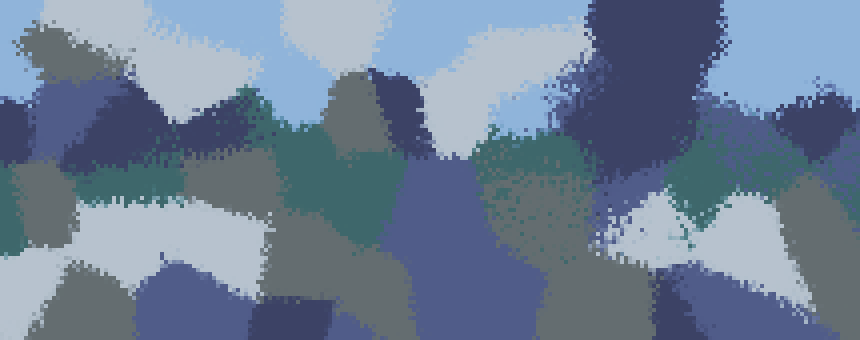

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([2, 4]) bbox
torch.Size([2])
IN IOUS max_iou
True
torch.Size([4, 4]) bbox
torch.Size([4])
IN IOUS max_iou
True
torch.Size([15, 4]) bbox
torch.Size([15])
IN IOUS max_iou
update_mesh tensor(0.4764, device='cuda:0', dtype=torch.float64, grad_fn=<MeanBackward0>)
85 215 no


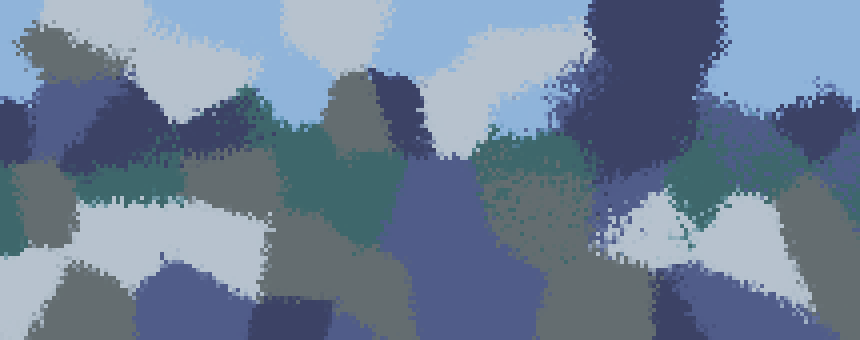

IN SYNTHS
torch.Size([4, 4, 800, 800]) torch.Size([4, 3, 416, 416])
torch.Size([4, 3, 800, 800])
4
True
torch.Size([5, 4]) bbox
torch.Size([5])
IN IOUS max_iou
True
torch.Size([8, 4]) bbox
torch.Size([8])
IN IOUS max_iou
True
torch.Size([54, 4]) bbox
torch.Size([54])
IN IOUS max_iou
True
torch.Size([10, 4]) bbox
torch.Size([10])
IN IOUS max_iou
  EPOCH NR:  0
EPOCH LOSS:  0.37079767866971647
  DET LOSS:  0.9040908712021848
 MEAN PROB:  0.9040908712021848
   TV LOSS:  0.0
 CTRL LOSS:  0.005607771759340634
 SEED LOSS:  0.0
EPOCH TIME:  39.96175169944763


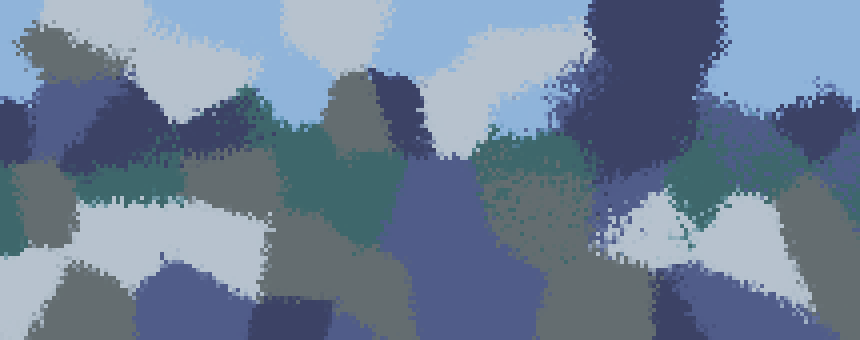

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:39<00:00, 39.97s/it]


In [118]:
trainer = PatchTrainer(args)
trainer.train()

# Voronoi pass

Used GPU:  <NVIDIA GeForce RTX 3090 Ti on Platform: NVIDIA CUDA (2 refs)>


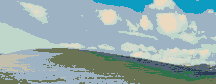

Number of objects in the image: 25.0


In [32]:
import pyclesperanto_prototype as cle
from skimage.io import imread, imsave
from PIL import Image
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
import numpy as np
# initialize / select GPU with "TX" in their name
device = cle.select_device("TX")
print("Used GPU: ", device)

im = Image.open("xp.png")
# im = rgb2gray(im)
# plt.imshow(im)
# plt.pause(0.1)
# plt.cla()
im.show()
im = np.array(im)

# process the image
inverted = cle.subtract_image_from_scalar(im, scalar=255)
blurred = cle.gaussian_blur(inverted, sigma_x=1, sigma_y=1)
binary = cle.threshold_otsu(blurred)
labeled = cle.connected_components_labeling_box(binary)

# The maximium intensity in a label image corresponds to the number of objects
num_labels = labeled.max()
print(f"Number of objects in the image: {num_labels}")

# save image to disc
# Image.fromarray((np.array(labeled).astype(np.float32))/255).show()

In [33]:
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries
from skimage.util import img_as_float

In [36]:
# # segments.max()
from collections import defaultdict
def get_centroids(segments, img):
    centroid_x, centroid_y = [], []
    med_colors = []
    clusters = []
    grey_img = rgb2gray(img)
    
    for i in range(1, segments.max()+1):
        mask = np.where(segments==i, False, True)
        mask = np.stack([mask,mask,mask], axis=2)
        coordinates = np.argwhere(mask==False)
        x = np.array(coordinates[:, 0])
        y = np.array(coordinates[:, 1])

        centroid_x.append(x.mean())
        centroid_y.append(y.mean())

        masked_section = np.ma.array(img, mask=mask)
        color_set = defaultdict(int)
        for x in masked_section:
            for y in x:
                if not isinstance(y[0], np.ma.MaskedArray):
                    color_set[(y[0],y[1],y[2])] += 1
            
        most_seen = None
        most_seen_times = 0
        for color in color_set:
            if color_set[color] > most_seen_times:
                most_seen = color
                most_seen_times = color_set[color]
        
        med_colors.append(most_seen)
        # break

    return centroid_x, centroid_y, med_colors

In [54]:
numSegments = 90
image = img_as_float(imread("xp.png"))
segments = slic(image, n_segments=numSegments, sigma=5, convert2lab=True)
x, y, med_colors = get_centroids(segments, image)

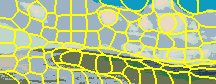

In [55]:
Image.fromarray(np.array(255*mark_boundaries(image, segments)).astype(np.uint8)).show()

In [57]:
from skimage.color import rgb2lab, deltaE_ciede2000

num_cells = len(med_colors)
num_colors = len(set(med_colors))
cells_per_color = num_cells // num_colors
color_counter = defaultdict(list)

color_sim_matrix = np.zeros((cells_per_color, cells_per_color))
for i in range(num_colors):
    for j in range(i+1, num_colors):
        color_sim_matrix[i, j] = 

for idx, m in enumerate(med_colors):
    color_counter[m].append()

for c in color_counter:
    if color_counter[c] = 

90


defaultdict(int,
            {(0.615686274509804, 0.6980392156862745, 0.7607843137254902): 48,
             (0.047058823529411764, 0.611764705882353, 0.7607843137254902): 4,
             (0.8274509803921568, 0.8588235294117647, 0.8117647058823529): 10,
             (0.9254901960784314, 0.8549019607843137, 0.7529411764705882): 2,
             (0.7490196078431373, 0.8392156862745098, 0.796078431372549): 7,
             (0.4156862745098039,
              0.45098039215686275,
              0.32941176470588235): 12,
             (0.7607843137254902, 0.7529411764705882, 0.6745098039215687): 1,
             (0.1803921568627451, 0.44705882352941173, 0.29411764705882354): 2,
             (0.3254901960784314, 0.39215686274509803, 0.4549019607843137): 4})

In [172]:
for color in set(med_colors):
    print([int(color[0]*255), int(color[1]*255), int(color[2]*255)])

[236, 218, 192]
[83, 100, 116]
[12, 156, 194]
[105, 115, 84]
[211, 219, 207]
[191, 214, 203]
[46, 113, 75]
[157, 178, 194]
[194, 192, 172]


In [35]:
x = plt.imread("intermediate.png")
plt.imshow(x)

0, 49
27, 45
71, 35
85, 38
106, 39
119, 39
135, 39
176, 40
169, 43
205, 42

Error in callback <function _draw_all_if_interactive at 0x709e3fb82310> (for post_execute), with arguments args (),kwargs {}:


ValueError: object __array__ method not producing an array

ValueError: Output array must be a NumPy array

<Figure size 640x480 with 1 Axes>

In [36]:
x.shape

(364, 864, 4)